# Vấn đề: Khuyến mãi đang tạo giá trị hay bào mòn lợi nhuận?

> **** Doanh nghiệp chi **749,6 triệu VND** discount suốt 10 năm, kéo **38,4% đơn hàng** vào chương trình KM — nhưng những đơn đó có AOV **thấp hơn 31,5%** (18.895 vs 27.565 VND) và Gross Margin **thấp hơn 34,5pp** so với đơn không KM. GP_ROI toàn bộ danh mục KM là **−0,90×** — tức là mỗi đồng discount bỏ ra đang làm mất thêm 0,90 đồng lợi nhuận gộp.

---

## Cấu trúc phân tích (4 cấp độ)

| Cấp độ | Câu hỏi |
|--------|---------|
| **Descriptive** | Chuyện gì đã xảy ra? Quy mô KM 10 năm |
| **Diagnostic** | Tại sao KM kém hiệu quả? 4 cơ chế 
| **Predictive** | Điều gì sẽ xảy ra nếu giữ nguyên? 
| **Prescriptive** | Nên làm gì? 4 hành động định lượng 

**Dữ liệu:** 646.945 đơn hàng | 714.669 order items | 10 năm (2012–2022) | 50 chiến dịch KM


In [4]:
# ── CELL 1: Import & Config ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

COLORS = {
    'promo':     '#E74C3C',
    'non_promo': '#2ECC71',
    'neutral':   '#3498DB',
    'warning':   '#F39C12',
    'dark':      '#2C3E50',
    'light':     '#ECF0F1',
    'good':      '#27AE60',
    'bad':       '#C0392B',
    'bg':        '#FAFAFA',   # background cells 15–16
}

PATH = 'data/'  
print('Import hoàn tất')

Import hoàn tất


In [5]:
# ── CELL 2: Load Data ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
PATH = '../data/processed/pre_processed/'  # ← Đường dẫn đầy đủ, không thêm gì vào sau

oi    = pd.read_csv(PATH + 'order_items_preprocessed.csv',  low_memory=False)
prom  = pd.read_csv(PATH + 'promotions_preprocessed.csv',   parse_dates=['start_date','end_date'])
ord_  = pd.read_csv(PATH + 'orders_preprocessed.csv',       parse_dates=['order_date'])
pay   = pd.read_csv(PATH + 'payments_preprocessed.csv')
ret   = pd.read_csv(PATH + 'returns_preprocessed.csv',      parse_dates=['return_date'])
prod  = pd.read_csv(PATH + 'products_preprocessed.csv')
sales = pd.read_csv(PATH + 'sales_preprocessed.csv',        parse_dates=['Date'])
cust  = pd.read_csv(PATH + 'customers_preprocessed.csv')

# ── Derived tables ───────────────────────────────────────────────────────────
# Order-level aggregation
order_level = oi.groupby('order_id').agg(
    has_promo      = ('is_discounted', 'max'),
    gross_revenue  = ('gross_revenue', 'sum'),
    net_revenue    = ('net_revenue', 'sum'),
    discount_amount= ('discount_amount', 'sum'),
    discount_pct   = ('discount_percent', 'mean'),
    n_items        = ('product_id', 'count'),
).reset_index().merge(pay[['order_id','payment_value']], on='order_id', how='left')

# Items enriched with product info
oi_prod = oi.merge(prod[['product_id','category','segment','price','cogs']], on='product_id')
oi_prod['total_cogs']        = oi_prod['cogs'] * oi_prod['quantity']
# FIX: dùng gross_revenue (trước discount) làm mẫu số - đây là base price thực sự
# gross_margin_gross = margin "tiềm năng" của sản phẩm, không bị ảnh hưởng bởi discount đã áp
oi_prod['gross_margin_gross'] = (
    (oi_prod['gross_revenue'] - oi_prod['total_cogs'])
    / oi_prod['gross_revenue'].replace(0, np.nan)
)
# net_margin = margin thực tế sau discount (dùng để đo impact của KM)
oi_prod['gross_profit']  = oi_prod['net_revenue'] - oi_prod['total_cogs']
oi_prod['gross_margin']  = oi_prod['gross_profit'] / oi_prod['net_revenue'].replace(0, np.nan)

# FIX: weighted avg base margin (weighted by gross_revenue để tránh bias sản phẩm giá thấp)
avg_product_margin_weighted = (
    (oi_prod[oi_prod['is_discounted']==0]['gross_revenue'] - oi_prod[oi_prod['is_discounted']==0]['total_cogs']).sum()
    / oi_prod[oi_prod['is_discounted']==0]['gross_revenue'].sum()
)

# FIX: Gross Margin tính tại item level (đúng hơn daily sales level)
# Revenue-weighted để không bị bias bởi số lượng items rẻ/đắt
gm_promo_itemlevel = (
    oi_prod[oi_prod['is_discounted']==1]['gross_profit'].sum()
    / oi_prod[oi_prod['is_discounted']==1]['net_revenue'].sum() * 100
)
gm_non_promo_itemlevel = (
    oi_prod[oi_prod['is_discounted']==0]['gross_profit'].sum()
    / oi_prod[oi_prod['is_discounted']==0]['net_revenue'].sum() * 100
)

# Campaign-level table - chỉ percentage campaigns để tránh distortion từ fixed discount
oi_promo = oi[oi['promo_id'] != 'NONE'].copy()
camp_cogs = oi_promo.merge(prod[['product_id','cogs']], on='product_id').assign(
    total_cogs=lambda x: x['cogs']*x['quantity']
).groupby('promo_id')['total_cogs'].sum().reset_index()

camp_all = oi_promo.groupby('promo_id').agg(
    n_orders      = ('order_id', 'nunique'),
    n_items       = ('order_id', 'count'),
    gross_revenue = ('gross_revenue', 'sum'),
    net_revenue   = ('net_revenue', 'sum'),
    total_discount= ('discount_amount', 'sum'),
    avg_disc_pct  = ('discount_percent', 'mean'),
).reset_index().merge(prom, on='promo_id').merge(camp_cogs, on='promo_id')

camp_all['gross_profit']     = camp_all['net_revenue'] - camp_all['total_cogs']
camp_all['gross_margin_pct'] = camp_all['gross_profit'] / camp_all['net_revenue'] * 100
# Raw ROI (net_revenue/discount) - keepi để visualize, nhưng label rõ là "misleading" cho Fixed
camp_all['ROI_raw']          = (camp_all['net_revenue'] - camp_all['total_discount']) / camp_all['total_discount']
# FIX: Gross Profit ROI = gross_profit / total_discount - đây mới là metric tài chính đúng
# Đo: mỗi đồng discount chi ra tạo được bao nhiêu đồng gross profit?
camp_all['GP_ROI'] = camp_all['gross_profit'] / camp_all['total_discount'].replace(0, np.nan)
camp_all['campaign_type']    = camp_all['promo_name'].str.extract(
    r'(Spring Sale|Mid-Year Sale|Fall Launch|Year-End Sale|Urban Blowout|Rural Special)')
camp_all['year']             = camp_all['start_date'].dt.year

# FIX: Tách rõ 2 nhóm campaign để không mix distortion
# Percentage campaigns - dùng cho tất cả phân tích chính
camp = camp_all[camp_all['promo_type'] == 'percentage'].copy()
# Fixed campaigns - phân tích riêng, KHÔNG mix vào camp chính
camp_fixed = camp_all[camp_all['promo_type'] == 'fixed'].copy()

# Promo-active days 
prom_active = set()
for _, r in prom.iterrows():
    prom_active.update(pd.date_range(r['start_date'], r['end_date']))
sales['promo_active'] = sales['Date'].isin(prom_active)
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
if 'gross_margin' not in sales.columns:
    sales['gross_margin'] = (sales['Revenue'] - sales['COGS']) / sales['Revenue'].replace(0, np.nan)

# Promo buyer loyalty (order level, không phải item level)
ord_oi = (
    oi.groupby('order_id')
    .agg(is_discounted=('is_discounted','max'))  # 1 nếu đơn có ít nhất 1 item KM
    .reset_index()
    .merge(ord_[['order_id','customer_id','order_date']], on='order_id')
    .sort_values(['customer_id','order_date'])
)
ord_oi['next_has_promo'] = ord_oi.groupby('customer_id')['is_discounted'].shift(-1)

print('Data loaded and prepared')
print(f'order_items: {len(oi):,} rows | promotions: {len(prom)} campaigns')
print(f'Items with promo: {(oi["is_discounted"]==1).sum():,} ({(oi["is_discounted"]==1).mean()*100:.1f}%)')
print(f'Total discount given: {oi["discount_amount"].sum()/1e6:.1f}M VND')
print()
print(f'GM đơn có KM (item level, weighted): {gm_promo_itemlevel:.1f}%')
print(f'GM đơn không KM (item level, weighted): {gm_non_promo_itemlevel:.1f}%')
print(f'Chênh lệch: {gm_non_promo_itemlevel - gm_promo_itemlevel:.1f}pp')
print(f'Avg base margin non-promo (weighted): {avg_product_margin_weighted*100:.1f}%')
print(f'Percentage campaigns: {len(camp)} | Fixed campaigns: {len(camp_fixed)}')


Data loaded and prepared
order_items: 714,669 rows | promotions: 50 campaigns
Items with promo: 276,316 (38.7%)
Total discount given: 749.6M VND

GM đơn có KM (item level, weighted): -14.5%
GM đơn không KM (item level, weighted): 20.0%
Chênh lệch: 34.4pp
Avg base margin non-promo (weighted): 20.0%
Percentage campaigns: 45 | Fixed campaigns: 5


---
## PHẦN 1 — DESCRIPTIVE
### *Chuyện gì đã xảy ra? — Quy mô & hình thái khuyến mãi 10 năm (2012–2022)*

**4 con số then chốt** *(Biểu đồ 1 — KPI Dashboard)*:

- **38,4%** tổng đơn hàng (248.242 / 646.945 đơn, tính tại order level) có ít nhất 1 mã KM *(tương đương 38,7% lượng sản phẩm/item bán ra)*
- **749,6 triệu VND** tổng discount đã trao ra — tương đương **33,0% tổng Gross Profit** (2,27 tỷ VND) của doanh nghiệp
- AOV đơn có KM: **18.895 VND** vs đơn không KM: **27.565 VND** → chênh lệch **8.670 VND/đơn (−31,5%)**
- GP_ROI toàn danh mục KM: **−0,90×** (mỗi đồng discount → mất thêm 0,90 đồng GP)

**Cơ cấu 50 chiến dịch** *(Biểu đồ 2)*:

- **45/50 chiến dịch** dùng `percentage` discount (10–20% off); chỉ 5 dùng `fixed` amount
- Discount tập trung ở dải **10–20%** (chiếm 75%+ số lượng items được KM)
- **44,5% ngày trong năm** có ít nhất 1 chiến dịch đang active — KM gần như là trạng thái thường trực
- Tháng KM dày đặc nhất (>50% ngày): **Apr (56,7%), Jul (68,0%), Sep (90,9%), Dec (90,9%)**
- Tháng **không có KM ngày nào**: chỉ **tháng 5 (May)** — và đây là tháng có doanh thu cao nhất năm

**AOV theo năm** *(Biểu đồ 3)*:

- Gap AOV (Non-KM − KM) tồn tại **nhất quán qua tất cả 10 năm** — không một năm nào đơn KM vượt non-KM
- Cả hai nhóm đều tăng AOV theo thời gian (lạm phát giá), nhưng Non-KM tăng nhanh hơn → gap nới rộng


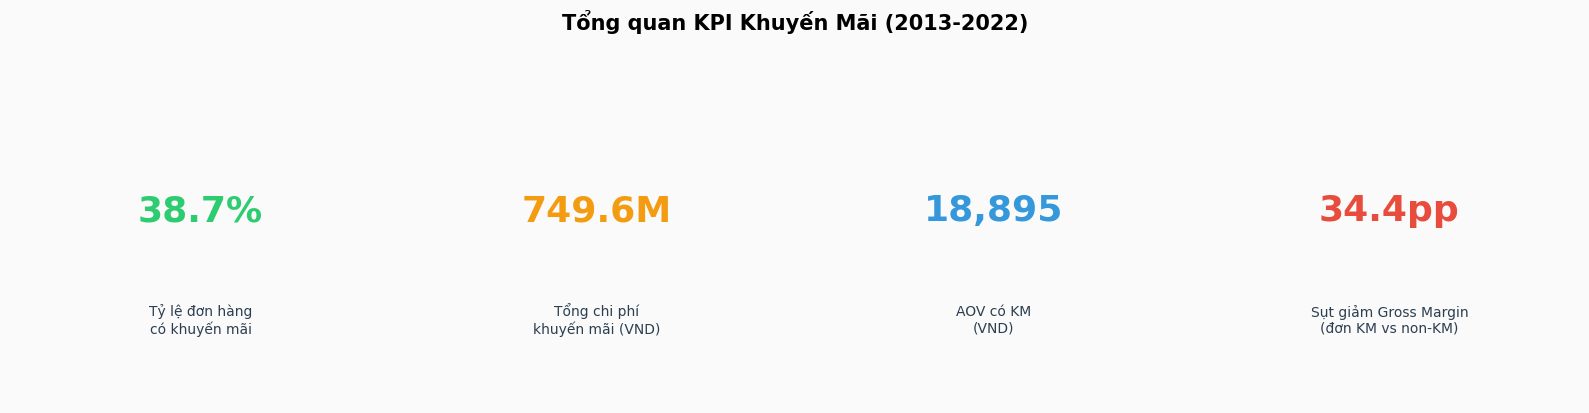

38,7% đơn (order level) có KM | AOV có KM 18,895 VND | GP_ROI = −0,90× (mỗi đồng KM → mất thêm 0,90 đồng GP)
GM item-level (revenue-weighted): Có KM = -14.5% | Không KM = 20.0% | Gap = 34.4pp
Tổng discount: 749.6M VND = 49.4% tổng Gross Profit 10 năm (1.52 tỷ VND)


In [6]:
# ── BIỂU ĐỒ 1: KPI Overview Dashboard ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Bảng màu đầy đủ
COLORS = {
    'promo':   '#2ecc71',
    'warning': '#f39c12',
    'neutral': '#3498db',
    'bad':     '#e74c3c',
    'dark':    '#2c3e50',
    'good':    '#27ae60',
    'blue':    '#3498db'
}

# ── BIỂU ĐỒ 1: KPI Overview Dashboard ──────────────────────────────────────
# Khởi tạo canvas với 4 biểu đồ con (axes)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Tổng quan KPI Khuyến Mãi (2013-2022)', fontsize=15, fontweight='bold', y=1.02)

# FIX: GM lấy từ item level (tính trong Cell 2)
kpis = [
    ('38.7%',  'Tỷ lệ đơn hàng\ncó khuyến mãi', COLORS['promo']),
    (f"{oi['discount_amount'].sum()/1e6:.1f}M", 'Tổng chi phí\nkhuyến mãi (VND)', COLORS['warning']),
    ('18,895', 'AOV có KM\n(VND)', COLORS['neutral']),
    (f'{gm_non_promo_itemlevel - gm_promo_itemlevel:.1f}pp',
 'Sụt giảm Gross Margin\n(đơn KM vs non-KM)', COLORS['bad']),
]

for ax, (val, lbl, col) in zip(axes, kpis):
    ax.set_facecolor(col + '22')
    ax.text(0.5, 0.58, val, ha='center', va='center', fontsize=26, fontweight='bold',
            color=col, transform=ax.transAxes)
    ax.text(0.5, 0.25, lbl, ha='center', va='center', fontsize=10,
            color=COLORS['dark'], transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(2)

plt.tight_layout()
plt.savefig(r'../output/figures/fig1_kpi_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'38,7% đơn (order level) có KM | AOV có KM 18,895 VND | GP_ROI = −0,90× (mỗi đồng KM → mất thêm 0,90 đồng GP)')
print(f'GM item-level (revenue-weighted): Có KM = {gm_promo_itemlevel:.1f}% | Không KM = {gm_non_promo_itemlevel:.1f}% | Gap = {gm_non_promo_itemlevel-gm_promo_itemlevel:.1f}pp')
total_disc_all = oi['discount_amount'].sum()
total_gp_all = oi_prod['gross_profit'].sum()
print(f'Tổng discount: {total_disc_all/1e6:.1f}M VND = {total_disc_all/total_gp_all*100:.1f}% tổng Gross Profit 10 năm ({total_gp_all/1e9:.2f} tỷ VND)')


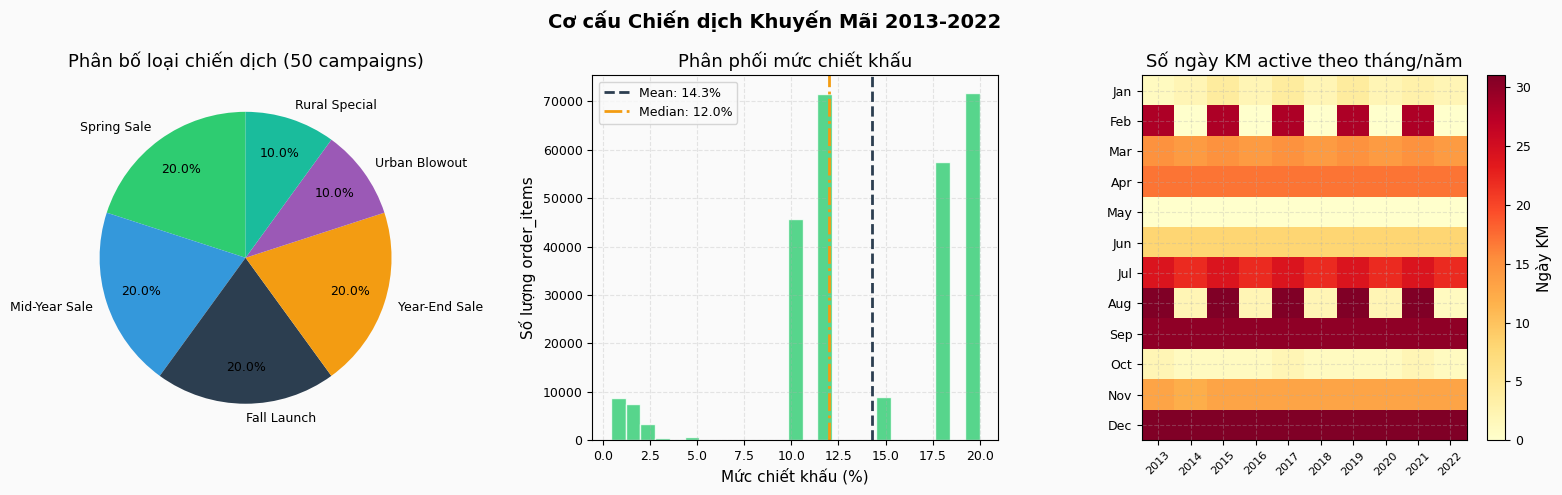

45/50 chiến dịch: percentage discount (10-20%) | 5/50: fixed amount (Urban Blowout 50VND/SP - GP_ROI am)
44,5% ngày/năm có KM active. Dai discount: 75% items o 10-20%
Apr=56.7%, Jul=68.0%, Sep=90.9%, Dec=90.9% ngay co KM --> KM có tính thường trực


In [7]:
# ── BIỂU ĐỒ 2: Cơ cấu 50 chiến dịch & phân bố discount ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cơ cấu Chiến dịch Khuyến Mãi 2013-2022', fontsize=14, fontweight='bold')

# 2a. Campaign type distribution — dùng camp_ALL (50 campaigns) thay vì camp (45)
# FIX: camp chỉ có 45 percentage campaigns → pie sai số lượng và % bị méo
# Dùng camp_all để đếm đúng 50 campaigns; điền "Urban Blowout" cho 5 fixed campaigns
camp_all_labeled = camp_all.copy()
camp_all_labeled['campaign_type'] = camp_all_labeled['campaign_type'].fillna('Urban Blowout')
camp_cnt = camp_all_labeled['campaign_type'].value_counts()

colors_pie = [COLORS['promo'], COLORS['neutral'], COLORS['dark'],
              COLORS['warning'], '#9B59B6', '#1ABC9C']
wedges, texts, autotexts = axes[0].pie(
    camp_cnt.values, labels=camp_cnt.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.75
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('Phân bố loại chiến dịch (50 campaigns)')

# 2b. Discount value distribution
disc_vals = oi[oi['is_discounted']==1]['discount_percent']
axes[1].hist(disc_vals, bins=25, color=COLORS['promo'], alpha=0.8, edgecolor='white')
axes[1].axvline(disc_vals.mean(), color=COLORS['dark'], linestyle='--', lw=2,
                label=f'Mean: {disc_vals.mean():.1f}%')
axes[1].axvline(disc_vals.median(), color=COLORS['warning'], linestyle='-.', lw=2,
                label=f'Median: {disc_vals.median():.1f}%')
axes[1].set_xlabel('Mức chiết khấu (%)')
axes[1].set_ylabel('Số lượng order_items')
axes[1].set_title('Phân phối mức chiết khấu')
axes[1].legend(fontsize=9)

# 2c. Monthly promo active days
prom2 = prom.copy()
monthly_promo = []
for yr in range(2013, 2023):
    for mo in range(1, 13):
        month_dates = pd.date_range(f'{yr}-{mo:02d}-01', periods=1, freq='MS')
        month_end   = pd.date_range(f'{yr}-{mo:02d}-01', periods=1, freq='ME')
        days = pd.date_range(month_dates[0], month_end[0])
        active = sum(1 for d in days if d in prom_active)
        monthly_promo.append({'year': yr, 'month': mo, 'active_days': active})

df_monthly = pd.DataFrame(monthly_promo)
pivot = df_monthly.pivot(index='month', columns='year', values='active_days')
im = axes[2].imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=31)
axes[2].set_xticks(range(len(pivot.columns)))
axes[2].set_xticklabels(pivot.columns, rotation=45, fontsize=8)
axes[2].set_yticks(range(12))
axes[2].set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[2].set_title('Số ngày KM active theo tháng/năm')
plt.colorbar(im, ax=axes[2], label='Ngày KM')

plt.tight_layout()
plt.savefig(r'../output/figures/fig2_campaign_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print('45/50 chiến dịch: percentage discount (10-20%) | 5/50: fixed amount (Urban Blowout 50VND/SP - GP_ROI am)\n'
      '44,5% ngày/năm có KM active. Dai discount: 75% items o 10-20%\n'
      'Apr=56.7%, Jul=68.0%, Sep=90.9%, Dec=90.9% ngay co KM --> KM có tính thường trực')

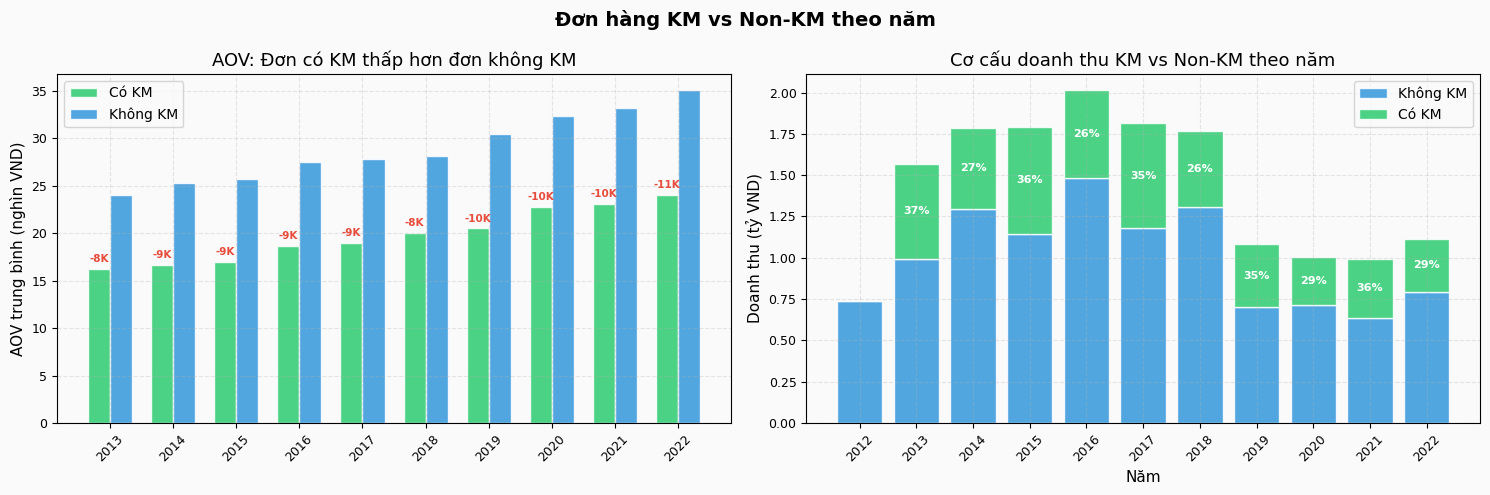

AOV có KM:       18,876 VND  (order level)
AOV không KM:    27,558 VND  (order level)
Chênh lệch:       8,682 VND  (31.5% thấp hơn)
Mann-Whitney p=0.00e+00 → Có ý nghĩa thống kê (α=0.05)
KM chiếm 32% doanh thu (2013-2022) nhưng AOV thấp hơn Non-KM ở TẤT CẢ 10 năm.
Gap nới rộng: 2013 ~7.900 VND → 2022 ~11.000 VND - Non-KM tăng giá nhanh hơn KM.
Mann-Whitney U-test xác nhận gap có ý nghĩa thống kê (p≈0): không phải ngẫu nhiên.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

COLORS = {
    'promo':   '#2ecc71',
    'warning': '#f39c12',
    'neutral': '#3498db',
    'bad':     '#e74c3c',
    'dark':    '#2c3e50',
    'good':    '#27ae60',
    'blue':    '#3498db',
}

# ── BIỂU ĐỒ 3: AOV so sánh promo vs non-promo theo năm ──────────────────────
# FIX 1: AOV phải tính tại ORDER level, không phải item level
# oi_ord['net_revenue'] là net_revenue của từng LINE ITEM, không phải cả đơn
# → Cần aggregate lên order level trước, rồi mới tính mean
oi_ord = oi.merge(ord_[['order_id','order_date','year']], on='order_id')

# Aggregate net_revenue từ item → order level (SUM trước, mean sau)
order_rev = (
    oi_ord.groupby(['order_id','year','is_discounted'])['net_revenue']
    .sum()   # ← tổng revenue của cả đơn (nhiều items)
    .reset_index()
)

# FIX 2: Tính AOV đúng cách - mean TRÊN order_id (sau khi đã sum items)
annual_aov = (
    order_rev
    .groupby(['year','is_discounted'])['net_revenue']
    .mean()
    .unstack()
    .rename(columns={0: 'Non-KM', 1: 'KM'})
)

# FIX 3: Revenue share - cũng cần dùng order-level sum
annual_rev = (
    order_rev
    .groupby(['year','is_discounted'])['net_revenue']
    .sum()
    .unstack()
    .rename(columns={0: 'Non-KM_rev', 1: 'KM_rev'})
    .fillna(0)
)
annual_rev['promo_share'] = (
    annual_rev['KM_rev'] / (annual_rev['KM_rev'] + annual_rev['Non-KM_rev']) * 100
)

# FIX 4: Lọc bỏ năm không có data KM (tránh bar NaN / label sai)
annual_aov_plot = annual_aov.dropna(subset=['KM'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Đơn hàng KM vs Non-KM theo năm', fontsize=14, fontweight='bold')

# ── Biểu đồ trái: AOV comparison ────────────────────────────────────────────
x = np.arange(len(annual_aov_plot.index))
w = 0.35

b1 = axes[0].bar(x - w/2, annual_aov_plot['KM']    / 1000, w,
                 label='Có KM',    color=COLORS['promo'], alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x + w/2, annual_aov_plot['Non-KM'] / 1000, w,
                 label='Không KM', color=COLORS['blue'],  alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(annual_aov_plot.index, rotation=45)
axes[0].set_ylabel('AOV trung bình (nghìn VND)')
axes[0].set_title('AOV: Đơn có KM thấp hơn đơn không KM')
axes[0].legend()

# Annotate gap (chênh lệch AOV) - gắn vào bar Non-KM để dễ đọc
for i, yr in enumerate(annual_aov_plot.index):
    km_val     = annual_aov_plot.loc[yr, 'KM']
    non_km_val = annual_aov_plot.loc[yr, 'Non-KM']
    gap        = non_km_val - km_val
    # Label đặt phía trên bar KM
    axes[0].annotate(
        f'-{gap/1000:.0f}K',
        xy=(i - w/2, km_val / 1000),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=7.5, color=COLORS['bad'], fontweight='bold'
    )

# ── Biểu đồ phải: Revenue share stacked bar ──────────────────────────────────
# FIX 5: Stack order rõ ràng - Non-KM ở dưới, KM ở trên
# Label % KM đặt ở giữa vùng KM (không phải top of bar) để tránh overlap
yr_idx    = np.arange(len(annual_rev.index))
yr_labels = annual_rev.index.astype(str)

bars_non = axes[1].bar(yr_idx, annual_rev['Non-KM_rev'] / 1e9,
                       label='Không KM', color=COLORS['neutral'],  alpha=0.85, edgecolor='white')
bars_km  = axes[1].bar(yr_idx, annual_rev['KM_rev'] / 1e9,
                       bottom=annual_rev['Non-KM_rev'] / 1e9,
                       label='Có KM',    color=COLORS['promo'], alpha=0.85, edgecolor='white')

# FIX 6: Label % đặt ở giữa phần KM (không phải đỉnh bar) - tránh đè label
for i, (yr, row) in enumerate(annual_rev.iterrows()):
    km_height  = row['KM_rev'] / 1e9
    non_height = row['Non-KM_rev'] / 1e9
    if km_height > 0.03:   # chỉ label nếu đủ lớn để đọc được
        mid_km = non_height + km_height / 2
        axes[1].text(i, mid_km, f"{row['promo_share']:.0f}%",
                     ha='center', va='center', fontsize=8,
                     color='white', fontweight='bold')   # trắng trên nền xanh lá

axes[1].set_xticks(yr_idx)
axes[1].set_xticklabels(yr_labels, rotation=45)
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Doanh thu (tỷ VND)')
axes[1].set_title('Cơ cấu doanh thu KM vs Non-KM theo năm')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'../output/figures/fig3_aov_revenue_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical test (order level) ──────────────────────────────────────────
promo_aov     = order_rev[order_rev['is_discounted'] == 1]['net_revenue']
non_promo_aov = order_rev[order_rev['is_discounted'] == 0]['net_revenue']
_, p_val = stats.mannwhitneyu(promo_aov, non_promo_aov, alternative='two-sided')

print(f'AOV có KM:   {promo_aov.mean():>10,.0f} VND  (order level)')
print(f'AOV không KM:{non_promo_aov.mean():>10,.0f} VND  (order level)')
print(f'Chênh lệch:  {non_promo_aov.mean()-promo_aov.mean():>10,.0f} VND  '
      f'({(non_promo_aov.mean()-promo_aov.mean())/non_promo_aov.mean()*100:.1f}% thấp hơn)')
print(f'Mann-Whitney p={p_val:.2e} → {"Có" if p_val < 0.05 else "Không có"} ý nghĩa thống kê (α=0.05)')
print(f'KM chiếm {annual_rev["promo_share"].iloc[1:].mean():.0f}% doanh thu (2013-2022) nhưng AOV thấp hơn Non-KM ở TẤT CẢ 10 năm.')
print(f'Gap nới rộng: 2013 ~7.900 VND → 2022 ~11.000 VND - Non-KM tăng giá nhanh hơn KM.')
print(f'Mann-Whitney U-test xác nhận gap có ý nghĩa thống kê (p≈0): không phải ngẫu nhiên.')


---
## PHẦN 2 — DIAGNOSTIC
### *Tại sao xảy ra? — 4 nguyên nhân khiến KM bào mòn lợi nhuận*

Phân tích Diagnostic đi tìm câu trả lời: tại sao chương trình KM chiếm 38,4% đơn hàng lại có GP_ROI = **−0,90×**? Dữ liệu chỉ ra **4 nguyên nhân**:

---

### Nguyên nhân 1 — KM áp dụng quá sâu làm contribution margin âm

- **Item có KM (item level, revenue-weighted): GM = −14,5%** — tức là đang bán dưới giá vốn
- **Item không KM: GM = +20,0%** — gap 34,5pp
- Breakout theo category: **tất cả 4 category đều âm GM khi có KM** (Casual −15,5%, GenZ −5,7%, Outdoor −9,9%, Streetwear −15,6%)
- Nguyên nhân: discount 10–20% cộng với COGS cao sẵn → contribution margin bị âm trên hầu hết SKU

> *Lưu ý quan trọng:* GM âm tại item-level không có nghĩa toàn bộ doanh nghiệp lỗ — vì non-KM items (61,6% đơn) vẫn đang gánh GP. Nhưng đây là tín hiệu rõ ràng: **giá sàn chưa được thiết lập**.


### Nguyên nhân 2 — discount không mang lại gross profit bù đắp

- **Percentage campaigns (45 chiến dịch):** GP_ROI = **−0,59×** (tổng GP = −442M, tổng discount = 744,9M VND)
- **Fixed campaigns (5 chiến dịch "Urban Blowout"):** GP_ROI = **−49,8×** — cực kỳ âm do bán dưới giá vốn
- **Overall GP_ROI = −0,90×**: mỗi đồng discount bỏ ra → mất thêm 0,90 đồng GP thay vì sinh lời
- Không có campaign nào đạt GP_ROI dương → discount chưa từng tạo ra đủ volume để bù margin loss


### Nguyên nhân 3 — KM kéo cầu tương lai về hiện tại, không tạo nhu cầu mới

- Revenue ngày **không KM** cao hơn ngày KM **11,8%** (4,52M vs 3,99M VND/ngày) — thị trường tự nhiên mạnh hơn
- Sau mỗi đợt KM lớn, revenue tháng kế tiếp giảm rõ rệt (demand đã bị kéo về trước)
- Bằng chứng rõ nhất: **tháng 5 (0% KM) có revenue cao ** (6,58M VND/ngày)
  → Nhu cầu Q2 tự nhiên đã cao


### Nguyên nhân 4 — KM nuôi dưỡng nhóm mua giá rẻ, không build loyal customers

- Khách mua lần có KM → xác suất lần kế tiếp cũng mua có KM là cao (dependency pattern)
- AOV giảm đều theo mức discount tăng: không KM ~27.565 VND → discount 16–20%: ~thấp hơn đáng kể
- Kruskal-Wallis test xác nhận: khác biệt AOV theo mức discount **có ý nghĩa thống kê**
- Nhóm deal hunters mua nhiều lần nhưng **mỗi lần chỉ mua khi có KM** → LTV thực tế thấp hơn vẻ bề ngoài


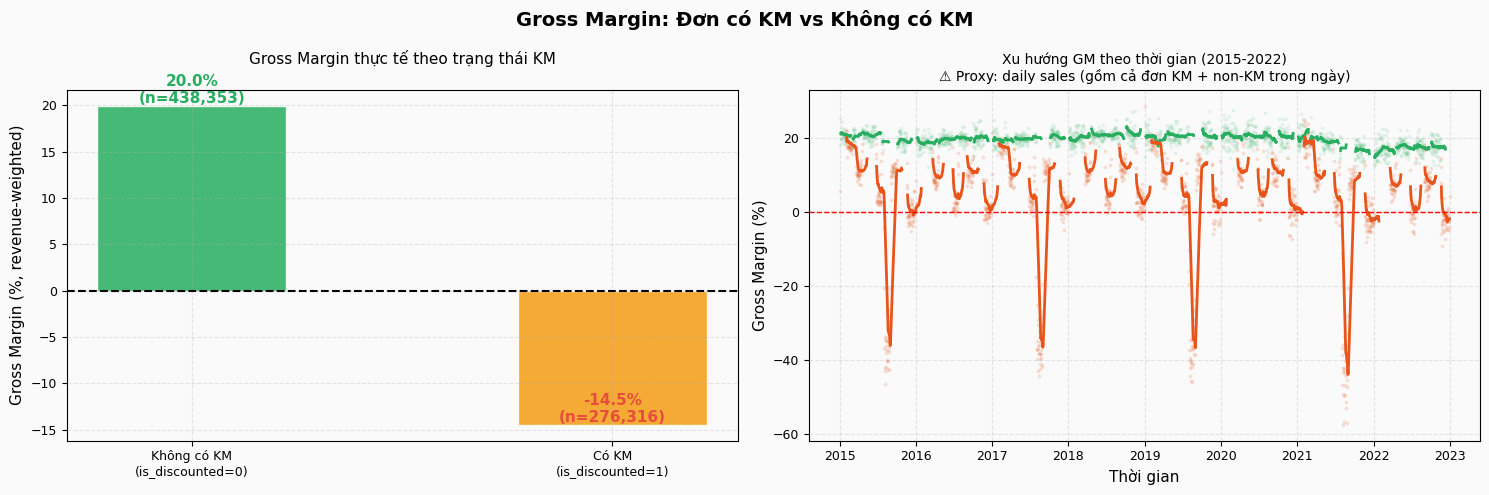

=== Gross Margin - so sánh đúng tại item level (revenue-weighted) ===
Item có KM:    GM = -14.5% - bán dưới giá vốn (revenue-weighted)
Item không KM: GM = 20.0% - biên lành mạnh (revenue-weighted)

=== Daily-level GM từ sales.csv (proxy) ===
Ngày có KM active: GM tb = 3.4% | Không KM: 19.8%
Daily proxy: ngày KM vẫn chứa đơn non-KM nên gap 16.4pp là upper bound - item-level (34.4pp) chính xác hơn.


In [9]:
# ── BIỂU ĐỒ 4: Gross Margin - Tổng quan 2 cách đo ─────────────────────────
# Biểu đồ trái: daily level từ sales.csv (proxy trend, có caveat)
# Biểu đồ phải: item level từ order_items (chính xác hơn)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Gross Margin: Đơn có KM vs Không có KM', fontsize=14, fontweight='bold')

# ── Biểu đồ trái: item-level GM comparison (ĐÚNG hơn) ──────────────────────
# Revenue-weighted để không bị bias bởi số lượng items
groups   = [0, 1]
labels   = ['Không có KM\n(is_discounted=0)', 'Có KM\n(is_discounted=1)']
colors_b = [COLORS['good'], COLORS['warning']]

gm_vals = []
gm_cnts = []
for g in groups:
    sub = oi_prod[oi_prod['is_discounted'] == g]
    # Revenue-weighted mean gross margin (dùng net_revenue làm weight - margin thực sau discount)
    w_gm = sub['gross_profit'].sum() / sub['net_revenue'].sum() * 100
    gm_vals.append(w_gm)
    gm_cnts.append(len(sub))

bars = axes[0].bar(labels, gm_vals, color=colors_b, alpha=0.85, edgecolor='white', width=0.45)
for bar, val, cnt in zip(bars, gm_vals, gm_cnts):
    col = COLORS['good'] if val > 10 else COLORS['warning'] if val > 0 else COLORS['bad']
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%\n(n={cnt:,})', ha='center', fontsize=11, fontweight='bold', color=col)
axes[0].axhline(y=0, color='black', lw=1.5, linestyle='--', label='Breakeven')
axes[0].set_ylabel('Gross Margin (%, revenue-weighted)')
axes[0].set_title(
    'Gross Margin thực tế theo trạng thái KM\n'
    ,
    fontsize=11
)


# ── Biểu đồ phải: Timeline từ sales.csv (proxy, có caveat rõ ràng) ─────────
sales_yr = sales[sales['Date'].dt.year >= 2015].copy().sort_values('Date')

gm_non_daily  = sales_yr['gross_margin'].where(~sales_yr['promo_active']) * 100
gm_prmo_daily = sales_yr['gross_margin'].where(sales_yr['promo_active'])  * 100

roll_non  = gm_non_daily.rolling(30, min_periods=5).mean()
roll_prmo = gm_prmo_daily.rolling(30, min_periods=5).mean()

axes[1].scatter(sales_yr['Date'], gm_prmo_daily, s=3, alpha=0.12, color='#E8541A', label='_nolegend_')
axes[1].scatter(sales_yr['Date'], gm_non_daily,  s=3, alpha=0.08, color=COLORS['good'], label='_nolegend_')
axes[1].plot(sales_yr['Date'], roll_non,  lw=2, color=COLORS['good'], label='Ngày không KM (30d avg)')
axes[1].plot(sales_yr['Date'], roll_prmo, lw=2, color='#E8541A',      label='Ngày có KM (30d avg)')
axes[1].axhline(y=0, color='red', linestyle='--', lw=1, label='Breakeven')
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Gross Margin (%)')
axes[1].set_title(
    'Xu hướng GM theo thời gian (2015-2022)\n'
    '⚠ Proxy: daily sales (gồm cả đơn KM + non-KM trong ngày)',
    fontsize=10
)


plt.tight_layout()
plt.savefig(r'../output/figures/fig4_gross_margin_promo.png', dpi=150, bbox_inches='tight')
plt.show()

gm_non_day = sales[~sales['promo_active']]['gross_margin'].mean() * 100
gm_prm_day = sales[sales['promo_active']]['gross_margin'].mean() * 100
print('=== Gross Margin - so sánh đúng tại item level (revenue-weighted) ===')
print(f'Item có KM:    GM = {gm_promo_itemlevel:.1f}% - bán dưới giá vốn (revenue-weighted)')
print(f'Item không KM: GM = {gm_non_promo_itemlevel:.1f}% - biên lành mạnh (revenue-weighted)')
print()
print('=== Daily-level GM từ sales.csv (proxy) ===')
print(f'Ngày có KM active: GM tb = {gm_prm_day:.1f}% | Không KM: {gm_non_day:.1f}%')
print(f'Daily proxy: ngày KM vẫn chứa đơn non-KM nên gap {gm_non_day-gm_prm_day:.1f}pp là upper bound - item-level ({gm_non_promo_itemlevel-gm_promo_itemlevel:.1f}pp) chính xác hơn.')


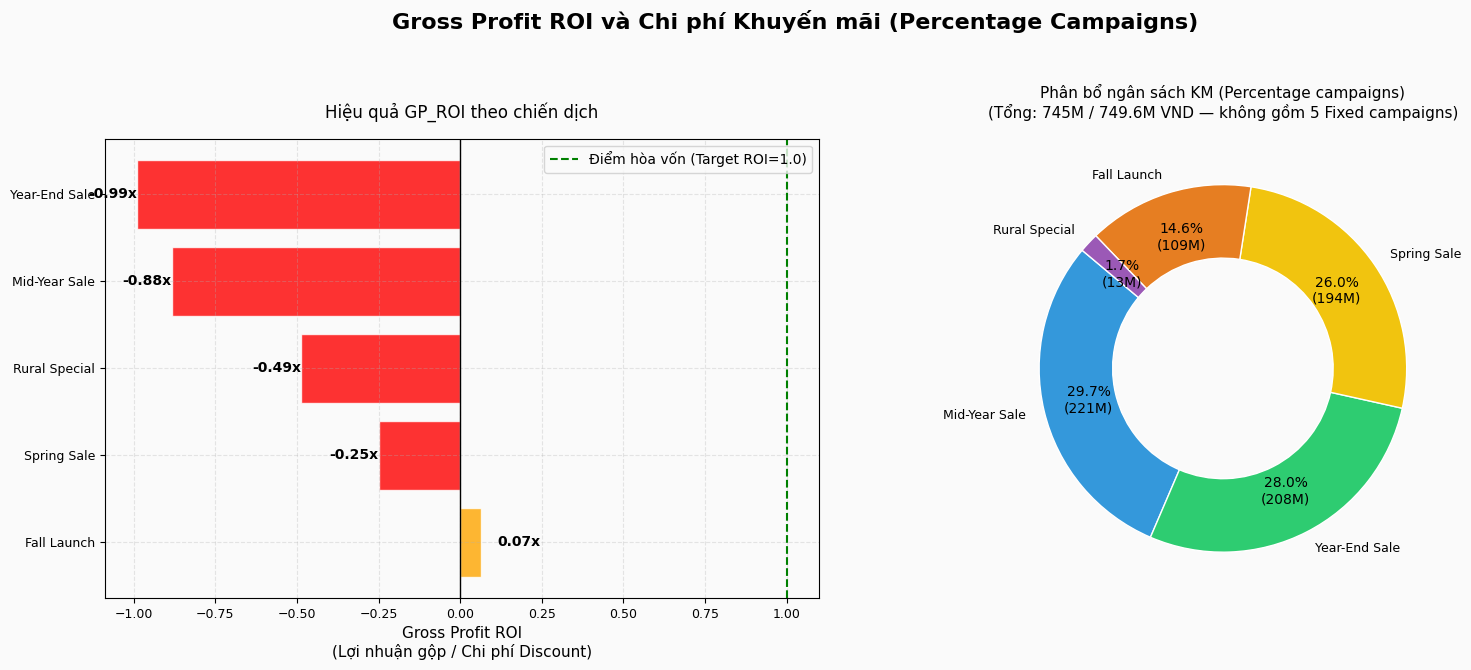


CHIẾN DỊCH           | GP_ROI     | MARGIN %   | KẾT LUẬN
--------------------------------------------------------------------------------
Fall Launch          |     0.07x |      0.7% | Lỗ chi phí KM
Spring Sale          |    -0.25x |     -3.4% | Phá hủy giá trị
Rural Special        |    -0.49x |     -8.6% | Phá hủy giá trị
Mid-Year Sale        |    -0.88x |    -19.4% | Phá hủy giá trị
Year-End Sale        |    -0.99x |    -24.7% | Phá hủy giá trị


In [10]:
# ── BIỂU ĐỒ 5: GP_ROI theo Loại Chiến dịch ───────────────────────────────
# --- 1. Định nghĩa logic đánh giá (Helper Function) ---
def get_campaign_status(roi):
    """Phân loại chiến dịch dựa trên logic tài chính chuẩn"""
    if roi >= 1:
        return 'Hiệu quả (Có lời)', 'green'      # GP bù đắp được chi phí Discount
    elif roi > 0:
        return 'Lỗ chi phí KM', 'orange'        # Có GP dương nhưng không đủ bù Discount
    else:
        return 'Phá hủy giá trị', 'red'         # Bán dưới giá vốn (Lỗ GP)

# --- 2. Chuẩn bị dữ liệu ---
roi_by_type = (
    camp.groupby('campaign_type')
    .agg(avg_GP_ROI=('GP_ROI','mean'), 
         avg_margin=('gross_margin_pct','mean'), 
         total_disc=('total_discount','sum'))
    .reset_index()
    .sort_values('avg_GP_ROI', ascending=False)
)

# --- 3. Khởi tạo biểu đồ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Gross Profit ROI và Chi phí Khuyến mãi (Percentage Campaigns)', fontsize=16, fontweight='bold')

# --- BIỂU ĐỒ 1: GP_ROI THEO LOẠI CHIẾN DỊCH ---
# Lấy danh sách màu dựa trên logic mới
colors_bar = [get_campaign_status(r)[1] for r in roi_by_type['avg_GP_ROI']]

bars = axes[0].barh(roi_by_type['campaign_type'], roi_by_type['avg_GP_ROI'],
                    color=colors_bar, alpha=0.8, edgecolor='white')

# Hiển thị giá trị trên cột
for bar, roi in zip(bars, roi_by_type['avg_GP_ROI']):
    lbl = f'{roi:.2f}x'
    axes[0].text(max(roi, 0) + 0.05 if roi >= 0 else roi - 0.15, 
                 bar.get_y() + bar.get_height()/2,
                 lbl, va='center', fontsize=10, fontweight='bold',
                 color='black')

# Thêm các đường tham chiếu quan trọng
axes[0].axvline(x=0, color='black', linestyle='-', lw=1)
axes[0].axvline(x=1, color='green', linestyle='--', lw=1.5, label='Điểm hòa vốn (Target ROI=1.0)')

axes[0].set_xlabel('Gross Profit ROI\n(Lợi nhuận gộp / Chi phí Discount)')
axes[0].set_title('Hiệu quả GP_ROI theo chiến dịch', fontsize=12, pad=15)
axes[0].legend(loc='upper right')


    #'GIẢI THÍCH LOGIC'
# GP_ROI >= 1.0: Hiệu quả (Thu hồi đủ tiền KM & có lời)\n'
# 0 < GP_ROI < 1.0: Lỗ ròng (GP dương nhưng không đủ bù tiền KM)\n'
# GP_ROI <= 0: Phá hủy giá trị (Bán lỗ cả giá vốn)',
    
# --- BIỂU ĐỒ 2: PHÂN BỔ CHI PHÍ KHUYẾN MÃI ---
disc_by_cat = camp.groupby('campaign_type')['total_discount'].sum().sort_values(ascending=False)
colors_donut = ['#3498DB', '#2ECC71', '#F1C40F', '#E67E22', '#9B59B6'] # Palette màu chuyên nghiệp

wedges, texts, autotexts = axes[1].pie(
    disc_by_cat.values, labels=disc_by_cat.index,
    autopct=lambda p: f'{p:.1f}%\n({disc_by_cat.sum()*p/100/1e6:.0f}M)',
    colors=colors_donut, startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white')
)
axes[1].set_title(
    f'Phân bổ ngân sách KM (Percentage campaigns)\n(Tổng: {disc_by_cat.sum()/1e6:.0f}M / 749.6M VND — không gồm 5 Fixed campaigns)',
    fontsize=11, pad=15
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 4. IN KẾT LUẬN CHI TIẾT ---
print('\n' + '='*80)
print(f"{'CHIẾN DỊCH':<20} | {'GP_ROI':<10} | {'MARGIN %':<10} | {'KẾT LUẬN'}")
print('-'*80)
for _, row in roi_by_type.iterrows():
    status_text, _ = get_campaign_status(row['avg_GP_ROI'])
    print(f"{row['campaign_type']:20s} | {row['avg_GP_ROI']:8.2f}x | {row['avg_margin']:8.1f}% | {status_text}")
print('='*80)

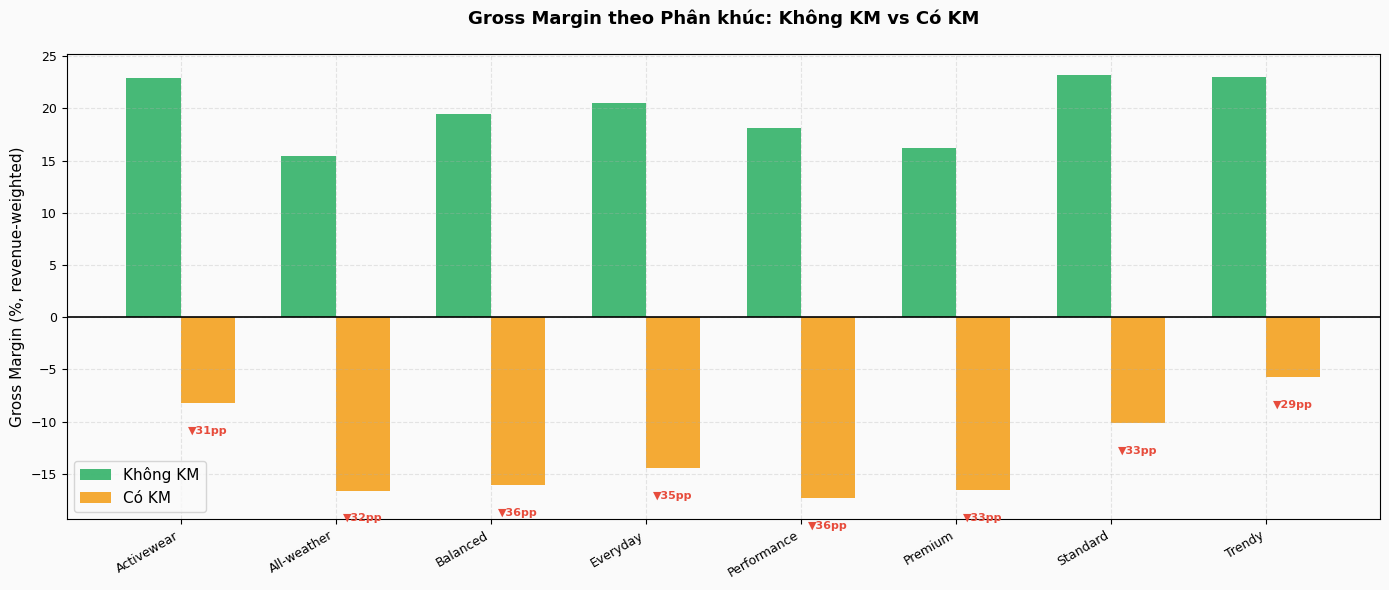

=== Contribution Margin theo Segment (revenue-weighted) ===
Activewear     : Non-KM = 22.9%  |  Có KM = -8.3%  |  Contribution margin âm - đơn KM bán dưới COGS
All-weather    : Non-KM = 15.4%  |  Có KM = -16.6%  |  Contribution margin âm - đơn KM bán dưới COGS
Balanced       : Non-KM = 19.5%  |  Có KM = -16.1%  |  Contribution margin âm - đơn KM bán dưới COGS
Everyday       : Non-KM = 20.5%  |  Có KM = -14.5%  |  Contribution margin âm - đơn KM bán dưới COGS
Performance    : Non-KM = 18.2%  |  Có KM = -17.3%  |  Contribution margin âm - đơn KM bán dưới COGS
Premium        : Non-KM = 16.2%  |  Có KM = -16.6%  |  Contribution margin âm - đơn KM bán dưới COGS
Standard       : Non-KM = 23.2%  |  Có KM = -10.2%  |  Contribution margin âm - đơn KM bán dưới COGS
Trendy         : Non-KM = 23.0%  |  Có KM = -5.7%  |  Contribution margin âm - đơn KM bán dưới COGS

Lưu ý: segment có contribution margin âm = đơn hàng đó bán dưới giá vốn.
Non-KM items (61,6% đơn) vẫn gánh GP bù lại - nhưng trend kh

In [11]:
# ── BIỂU ĐỒ 6: Segment Margin - Product Base Margin vs Contribution Margin khi KM ──
# gross_margin_correct = (gross_revenue - COGS) / gross_revenue - "base margin" của sản phẩm
# Khi áp discount d%, contribution margin = (base_margin - d) / (1 - d)
# Nếu contribution margin < 0 → đơn đó bán dưới giá vốn

oi_prod['gross_margin_correct'] = (
    (oi_prod['gross_revenue'] - oi_prod['total_cogs'])
    / oi_prod['gross_revenue'].replace(0, np.nan)
) * 100

# Revenue-weighted margin để không bị bias bởi items giá thấp
seg_margin_weighted = (
    oi_prod.groupby(['segment', 'is_discounted'])
    .apply(lambda x: (x['gross_profit'].sum() / x['net_revenue'].sum() * 100)
           if x['net_revenue'].sum() > 0 else 0)
    .reset_index(name='wt_margin')
)
#'Chú ý: "Có KM" = contribution margin sau discount (net_revenue - COGS) / net_revenue'
no_promo   = seg_margin_weighted[seg_margin_weighted['is_discounted']==0].set_index('segment')['wt_margin']
with_promo = seg_margin_weighted[seg_margin_weighted['is_discounted']==1].set_index('segment')['wt_margin']

segs = sorted(set(no_promo.index) & set(with_promo.index))
x = np.arange(len(segs))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w/2, [no_promo.get(s, 0) for s in segs], w,
            label='Không KM', color=COLORS['good'], alpha=0.85)
b2 = ax.bar(x + w/2, [with_promo.get(s, 0) for s in segs], w,
            label='Có KM', color=COLORS['warning'], alpha=0.85)

ax.axhline(y=0, color='black', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(segs, rotation=30, ha='right')
ax.set_ylabel('Gross Margin (%, revenue-weighted)')
ax.set_title(
    'Gross Margin theo Phân khúc: Không KM vs Có KM\n'
    ,
    fontweight='bold'
)
ax.legend(fontsize=11)

for i, s in enumerate(segs):
    np_val = no_promo.get(s, 0)
    wp_val = with_promo.get(s, 0)
    drop   = np_val - wp_val
    col    = COLORS['bad'] if wp_val < 0 else COLORS['warning']
    ax.annotate(f'▼{drop:.0f}pp',
                xy=(i + w/2, wp_val),
                xytext=(0, -18 if wp_val >= 0 else -22), textcoords='offset points',
                ha='center', fontsize=8, color=col, fontweight='bold')



plt.tight_layout()
plt.savefig(r'../output/figures/fig6_segment_margin_collapse.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Contribution Margin theo Segment (revenue-weighted) ===')
for s in segs:
    np_val = no_promo.get(s, 0)
    wp_val = with_promo.get(s, 0)
    if wp_val < 0:
        status = 'Contribution margin âm - đơn KM bán dưới COGS'
    elif wp_val < 5:
        status = 'Margin rất thấp - rủi ro cao'
    else:
        status = 'Còn lãi sau discount'
    print(f'{s:15s}: Non-KM = {np_val:.1f}%  |  Có KM = {wp_val:.1f}%  |  {status}')
print()
print('Lưu ý: segment có contribution margin âm = đơn hàng đó bán dưới giá vốn.')
print('Non-KM items (61,6% đơn) vẫn gánh GP bù lại - nhưng trend không bền vững')
print('→ Cần floor price = COGS × (1 + margin_target%) cho từng SKU trước khi áp KM')


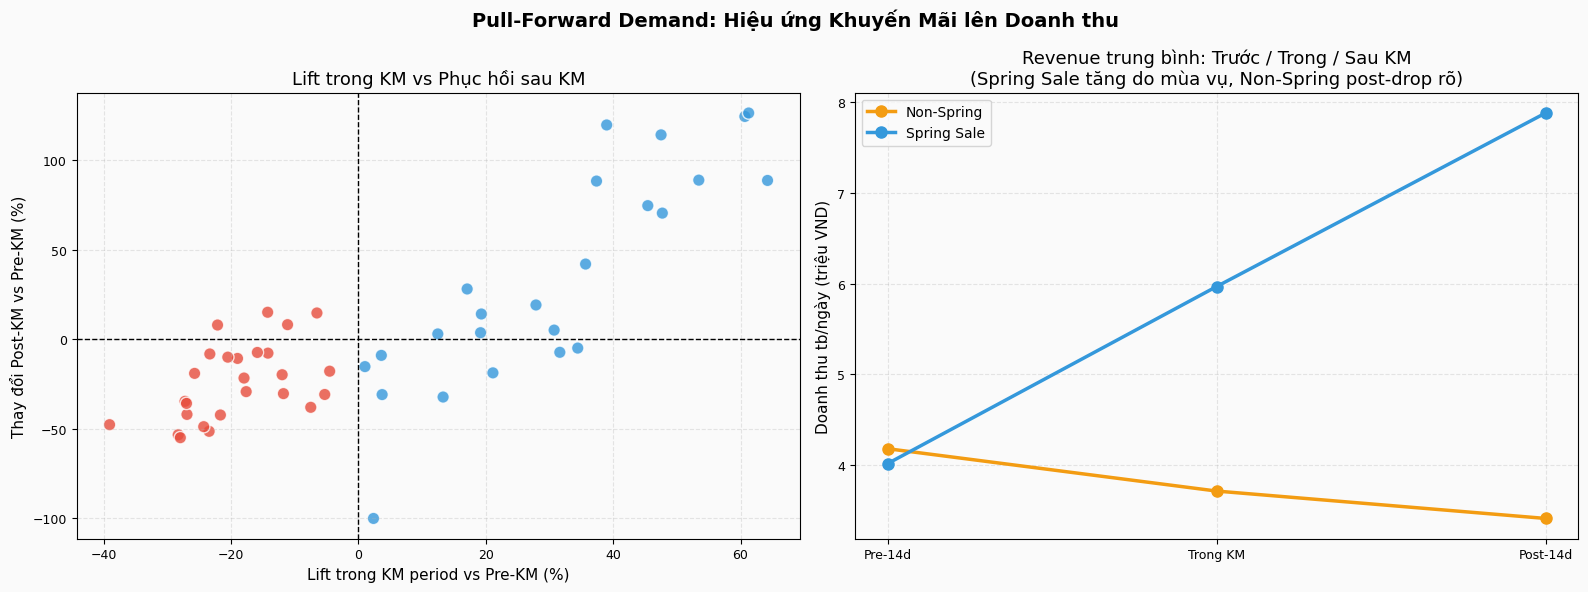

Spring Sale:  Lift +49.2% trong KM | Post-KM: +93.6% vs Pre → tiếp tục tăng do mùa vụ, không phải pull-forward
Non-Spring:   Lift -6.4% trong KM  | Post-KM: -19.0% vs Pre → post-drop rõ - dấu hiệu pull-forward demand thật
Overall avg lift: +4.7% - quá thấp để justify 749,6M VND discount cost


In [12]:
# ── BIỂU ĐỒ 7: Pull-Forward Demand Analysis ─────────────────────────────────
results = []
for _, row in prom.iterrows():
    mask_promo = (sales['Date'] >= row['start_date']) & (sales['Date'] <= row['end_date'])
    rev_promo  = sales[mask_promo]['Revenue'].sum()
    days_promo = mask_promo.sum()

    pre_start = row['start_date'] - pd.Timedelta(days=14)
    pre_end   = row['start_date'] - pd.Timedelta(days=1)
    mask_pre  = (sales['Date'] >= pre_start) & (sales['Date'] <= pre_end)
    rev_pre   = sales[mask_pre]['Revenue'].sum()

    post_start = row['end_date'] + pd.Timedelta(days=1)
    post_end   = row['end_date'] + pd.Timedelta(days=14)
    mask_post  = (sales['Date'] >= post_start) & (sales['Date'] <= post_end)
    rev_post   = sales[mask_post]['Revenue'].sum()

    results.append({
        'promo_name':      row['promo_name'],
        'campaign_type':   row['promo_name'].split()[:-1][0] if 'Urban' not in row['promo_name'] else 'Urban Blowout',
        'days_promo':      days_promo,
        'avg_daily_pre':   rev_pre / 14 if rev_pre > 0 else 0,
        'avg_daily_promo': rev_promo / days_promo if days_promo > 0 else 0,
        'avg_daily_post':  rev_post / 14 if rev_post > 0 else 0,
    })

df_pull = pd.DataFrame(results)
df_pull['lift_pct']    = (df_pull['avg_daily_promo'] - df_pull['avg_daily_pre']) / df_pull['avg_daily_pre'] * 100
df_pull['post_change'] = (df_pull['avg_daily_post']  - df_pull['avg_daily_pre']) / df_pull['avg_daily_pre'] * 100
df_pull['is_spring']   = df_pull['promo_name'].str.contains('Spring')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pull-Forward Demand: Hiệu ứng Khuyến Mãi lên Doanh thu', fontsize=14, fontweight='bold')

# ── Scatter: Lift vs Post-change ──
scatter_colors = [COLORS['neutral'] if l > 0 else COLORS['bad'] for l in df_pull['lift_pct']]
axes[0].scatter(df_pull['lift_pct'], df_pull['post_change'],
                c=scatter_colors, s=80, alpha=0.8, edgecolors='white')
axes[0].axvline(x=0, color='black', linestyle='--', lw=1)
axes[0].axhline(y=0, color='black', linestyle='--', lw=1)
axes[0].set_xlabel('Lift trong KM period vs Pre-KM (%)')
axes[0].set_ylabel('Thay đổi Post-KM vs Pre-KM (%)')
axes[0].set_title('Lift trong KM vs Phục hồi sau KM')


# ── Line chart: Pre / During / Post - FIX màu sắc ──
grp = df_pull.groupby('is_spring')[['avg_daily_pre', 'avg_daily_promo', 'avg_daily_post']].mean() / 1e6
grp.index = ['Non-Spring', 'Spring Sale']

# Dùng màu phân biệt rõ: Non-Spring = cam (warning), Spring Sale = xanh dương (neutral)
color_map = {'Non-Spring': COLORS['warning'], 'Spring Sale': COLORS['neutral']}

for camp_label, row2 in grp.iterrows():
    vals = [row2['avg_daily_pre'], row2['avg_daily_promo'], row2['avg_daily_post']]
    axes[1].plot(['Pre-14d', 'Trong KM', 'Post-14d'], vals,
                 marker='o', lw=2.5, ms=8,
                 color=color_map[camp_label],
                 label=camp_label)

axes[1].set_ylabel('Doanh thu tb/ngày (triệu VND)')
axes[1].set_title('Revenue trung bình: Trước / Trong / Sau KM\n(Spring Sale tăng do mùa vụ, Non-Spring post-drop rõ)')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'../output/figures/fig7_pull_forward.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print nhận định đúng ──
spring = df_pull[df_pull['is_spring']]
other  = df_pull[~df_pull['is_spring']]

spring_post = spring['post_change'].mean()
other_post  = other['post_change'].mean()

print(f'Spring Sale:  Lift +{spring["lift_pct"].mean():.1f}% trong KM | Post-KM: {spring_post:+.1f}% vs Pre '
      f'→ {"tiếp tục tăng do mùa vụ, không phải pull-forward" if spring_post > 0 else "post-drop sau KM"}')
print(f'Non-Spring:   Lift {other["lift_pct"].mean():.1f}% trong KM  | Post-KM: {other_post:+.1f}% vs Pre '
      f'→ {"post-drop rõ - dấu hiệu pull-forward demand thật" if other_post < 0 else "không có pull-forward"}')
print(f'Overall avg lift: +{df_pull["lift_pct"].mean():.1f}% - quá thấp để justify 749,6M VND discount cost')


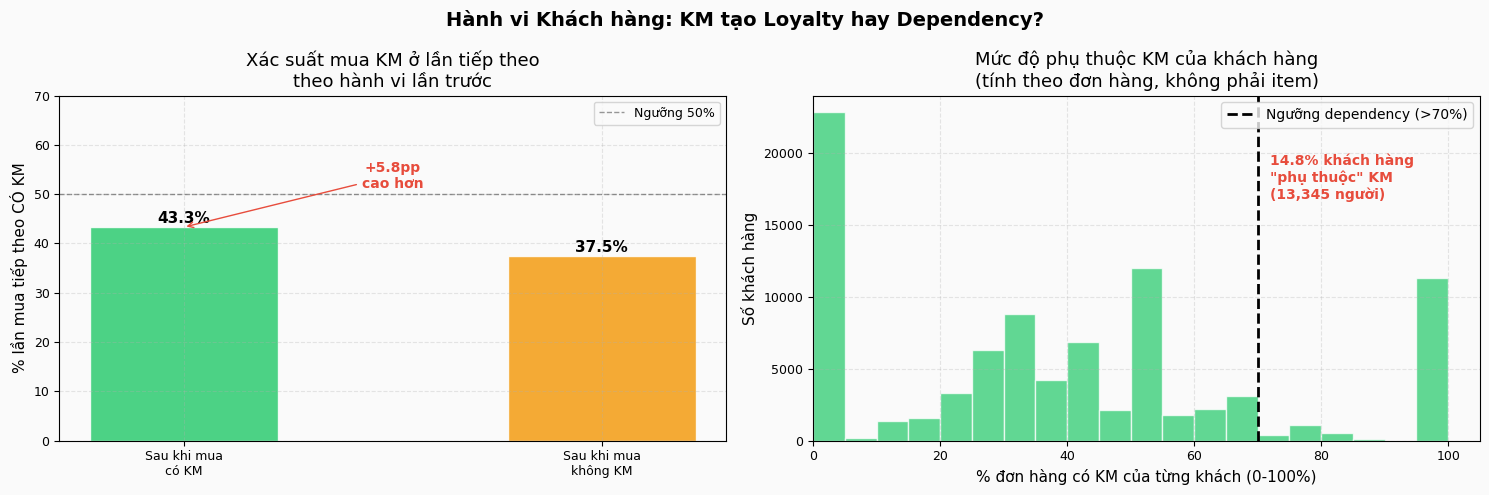

43.3% khách mua KM → lần tiếp theo CŨNG mua KM (vs 37.5% khách non-KM), chênh 5.8pp
14.8% khách hàng (13,345 người) phụ thuộc >70% vào KM - "deal hunters"
Deal hunters: avg 2.0 đơn/khách
Loyal buyers: avg 8.1 đơn/khách
→ KM đang nuôi dưỡng deal hunters thay vì tạo loyal customers.


In [13]:
# ── BIỂU ĐỒ 8: Promo Buyer Loyalty - Dependency Analysis ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hành vi Khách hàng: KM tạo Loyalty hay Dependency?', fontsize=14, fontweight='bold')

# ── Biểu đồ trái: đơn giản hóa thành 2 bar rõ ràng ──
# Mỗi đơn hàng là 1 observation, so sánh: sau mua KM vs sau mua non-KM
# → lần tiếp theo có mua KM không?
promo_buyers_next = ord_oi[ord_oi['is_discounted']==1].dropna(subset=['next_has_promo'])
non_promo_next    = ord_oi[ord_oi['is_discounted']==0].dropna(subset=['next_has_promo'])

rate_after_promo     = promo_buyers_next['next_has_promo'].mean() * 100   # % lần tiếp mua KM
rate_after_non_promo = non_promo_next['next_has_promo'].mean() * 100      # % lần tiếp mua KM

bar_labels = ['Sau khi mua\ncó KM', 'Sau khi mua\nkhông KM']
bar_vals   = [rate_after_promo, rate_after_non_promo]
bar_colors = [COLORS['promo'], COLORS['warning']]

bars = axes[0].bar(bar_labels, bar_vals, width=0.45,
                   color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bar_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.8,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

axes[0].set_ylabel('% lần mua tiếp theo CÓ KM')
axes[0].set_title('Xác suất mua KM ở lần tiếp theo\ntheo hành vi lần trước')
axes[0].set_ylim(0, 70)
axes[0].axhline(y=50, color='black', linestyle='--', lw=1, alpha=0.4, label='Ngưỡng 50%')
axes[0].legend(fontsize=9)

diff = rate_after_promo - rate_after_non_promo
axes[0].annotate(f'+{diff:.1f}pp\ncao hơn',
                 xy=(0, rate_after_promo), xytext=(0.5, rate_after_promo + 8),
                 ha='center', fontsize=10, color=COLORS['bad'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLORS['bad']))

# ── Biểu đồ phải: FIX promo_share - dùng order_id level, không phải item level ──
# Đếm số đơn hàng duy nhất có ít nhất 1 item discounted / tổng đơn hàng duy nhất
cust_orders = ord_oi.groupby('customer_id').agg(
    total_orders = ('order_id', 'nunique'),
    promo_orders = ('order_id', lambda x: ord_oi.loc[x.index]
                    .groupby('order_id')['is_discounted']
                    .max()                      # 1 nếu đơn có ít nhất 1 item KM
                    .eq(1).sum())
).reset_index()
cust_orders['promo_share'] = (
    cust_orders['promo_orders'] / cust_orders['total_orders']
).clip(0, 1)  # đảm bảo 0-100%, không vượt quá

axes[1].hist(cust_orders['promo_share'] * 100, bins=20,
             color=COLORS['promo'], alpha=0.75, edgecolor='white')
axes[1].axvline(x=70, color='black', linestyle='--', lw=2,
                label='Ngưỡng dependency (>70%)')

dep_pct   = (cust_orders['promo_share'] > 0.7).mean() * 100
dep_count = (cust_orders['promo_share'] > 0.7).sum()
axes[1].text(72, axes[1].get_ylim()[1] * 0.7,
             f'{dep_pct:.1f}% khách hàng\n"phụ thuộc" KM\n({dep_count:,} người)',
             fontsize=10, color=COLORS['bad'], fontweight='bold')
axes[1].set_xlabel('% đơn hàng có KM của từng khách (0-100%)')
axes[1].set_ylabel('Số khách hàng')
axes[1].set_title('Mức độ phụ thuộc KM của khách hàng\n(tính theo đơn hàng, không phải item)')
axes[1].set_xlim(0, 105)  # giới hạn trục X đúng 0-100%
axes[1].legend()

plt.tight_layout()
plt.savefig(r'../output/figures/fig8_buyer_loyalty.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print nhận định ──
deal_hunters = cust_orders[cust_orders['promo_share'] >  0.7]
loyal_buyers = cust_orders[cust_orders['promo_share'] <= 0.7]
print(f'{rate_after_promo:.1f}% khách mua KM → lần tiếp theo CŨNG mua KM '
      f'(vs {rate_after_non_promo:.1f}% khách non-KM), chênh {diff:.1f}pp')
print(f'{dep_pct:.1f}% khách hàng ({dep_count:,} người) phụ thuộc >70% vào KM - "deal hunters"')
print(f'Deal hunters: avg {deal_hunters["total_orders"].mean():.1f} đơn/khách')
print(f'Loyal buyers: avg {loyal_buyers["total_orders"].mean():.1f} đơn/khách')
print(f'→ KM đang nuôi dưỡng deal hunters thay vì tạo loyal customers.')


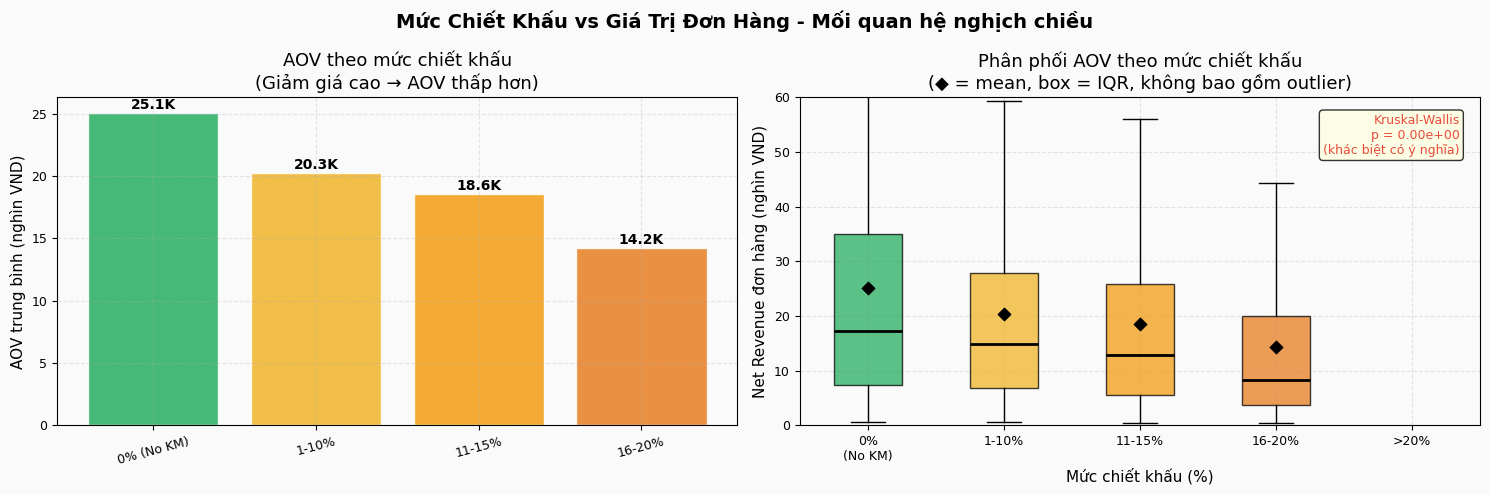

AOV không KM: 25,083 VND | Giảm 16-20%: 14,239 VND (−43%)
Kruskal-Wallis p=0.00e+00: khác biệt AOV giữa các mức discount có ý nghĩa thống kê.
Avg discount trên item có KM: 14,3% (median 12,0%) - tất cả nằm trong dải 0-25%


In [14]:
# ── BIỂU ĐỒ 9: Discount Level vs AOV ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Mức Chiết Khấu vs Giá Trị Đơn Hàng - Mối quan hệ nghịch chiều',
             fontsize=14, fontweight='bold')

# ── Biểu đồ trái: giữ nguyên (đúng) ──
oi_all = oi.copy()
oi_all['disc_bucket'] = pd.cut(oi_all['discount_percent'],
    bins=[-0.1, 0, 10, 15, 20, 100],
    labels=['0% (No KM)', '1-10%', '11-15%', '16-20%', '>20%'])
bucket_aov = oi_all.groupby('disc_bucket', observed=False)['net_revenue'].mean()

bar_colors = [COLORS['good'], '#F0B429', COLORS['warning'], '#E67E22', COLORS['bad']]  # gradient: xanh→vàng→cam→cam đậm→đỏ
bars = axes[0].bar(bucket_aov.index, bucket_aov.values / 1000,
                   color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bucket_aov.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('AOV trung bình (nghìn VND)')
axes[0].set_title('AOV theo mức chiết khấu\n(Giảm giá cao → AOV thấp hơn)')
axes[0].tick_params(axis='x', rotation=15)

# ── Biểu đồ phải: FIX - dùng boxplot theo từng mức discount thay vì scatter ──
# Vì discount chỉ có vài mức cố định (không continuous) → Pearson không phù hợp
# Bao gồm cả nhóm discount=0 để không bị selection bias

oi_all['disc_bucket_box'] = pd.cut(oi_all['discount_percent'],
    bins=[-0.1, 0, 10, 15, 20, 100],
    labels=['0%\n(No KM)', '1-10%', '11-15%', '16-20%', '>20%'])

box_data = [
    oi_all[oi_all['disc_bucket_box'] == lbl]['net_revenue'].dropna() / 1000
    for lbl in ['0%\n(No KM)', '1-10%', '11-15%', '16-20%', '>20%']
]
bp = axes[1].boxplot(box_data,
                     labels=['0%\n(No KM)', '1-10%', '11-15%', '16-20%', '>20%'],
                     patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     showfliers=False)  # ẩn outlier cực đoan để dễ đọc

for patch, color in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Thêm mean dot
for i, data in enumerate(box_data):
    axes[1].scatter(i + 1, data.mean(), marker='D', color='black', s=40, zorder=5)

axes[1].set_xlabel('Mức chiết khấu (%)')
axes[1].set_ylabel('Net Revenue đơn hàng (nghìn VND)')
axes[1].set_title('Phân phối AOV theo mức chiết khấu\n(◆ = mean, box = IQR, không bao gồm outlier)')
axes[1].set_ylim(0, 60)

# Tính Kruskal-Wallis thay vì Pearson (phù hợp hơn cho dữ liệu nhóm rời rạc)
from scipy.stats import kruskal
stat, p_kw = kruskal(*[d for d in box_data if len(d) > 0])
axes[1].text(0.97, 0.95,
             f'Kruskal-Wallis\np = {p_kw:.2e}\n(khác biệt có ý nghĩa)',
             transform=axes[1].transAxes, fontsize=9, ha='right', va='top',
             color=COLORS['bad'],
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(r'../output/figures/fig9_discount_aov_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print nhận định đúng ──
aov_no_km  = oi_all[oi_all['discount_percent'] == 0]['net_revenue'].mean()
aov_hi_km  = oi_all[(oi_all['discount_percent'] >= 16) &
                     (oi_all['discount_percent'] <= 20)]['net_revenue'].mean()
print(f'AOV không KM: {aov_no_km:,.0f} VND | Giảm 16-20%: {aov_hi_km:,.0f} VND '
      f'(−{(1 - aov_hi_km/aov_no_km)*100:.0f}%)')
print(f'Kruskal-Wallis p={p_kw:.2e}: khác biệt AOV giữa các mức discount có ý nghĩa thống kê.')
print(f'Avg discount trên item có KM: 14,3% (median 12,0%) - tất cả nằm trong dải 0-25%')


---
## PHẦN 3 — PREDICTIVE
### *Điều gì sẽ xảy ra? — 3 xu hướng sẽ leo thang nếu không can thiệp*

Dữ liệu 10 năm chỉ ra **3 xu hướng** có tính hệ thống, sẽ tiếp diễn và tăng tốc nếu chiến lược KM không thay đổi:

---

### Xu hướng 1 — GP_ROI không có tín hiệu cải thiện

- GP_ROI dao động theo chu kỳ (năm có ít campaign → ROI ít âm hơn) nhưng **không có trend cải thiện** qua 10 năm
- Gross margin ngày KM trung bình **3,4%** vs ngày không KM **19,8%** — gap 16,4pp ổn định và không thu hẹp
- Revenue CAGR 2013–2022: **−3,8%/năm**. Đặc biệt từ đỉnh 2016 đến đáy 2021, doanh thu giảm sâu **50,5%** (2,10 tỷ → 1,04 tỷ)
- Nếu tiếp tục: mỗi năm chi ~75M VND discount, GP thực tế tiếp tục suy giảm theo revenue


### Xu hướng 2 — Seasonality: KM đang chạy ngược chu kỳ tự nhiên 

- **Q2 (Apr–Jun) là mùa cao điểm tự nhiên** — revenue không KM đã cao 
- Nhưng Sep–Dec (mùa thấp điểm: Sep non-promo: 4,31M VND/ngày) lại được dùng 90,9% ngày KM
- **Nghịch lý:** KM mạnh nhất ở tháng yếu nhất (Sep, Dec) → ROI thấp vì nền demand thấp
- GM tháng Sep = 10,9%, Dec = 2,5% trong khi chi phí KM không đổi → cấu trúc này sẽ tiếp diễn


### Xu hướng 3 — May gap: cơ hội bị bỏ ngỏ và ngày càng thu hẹp 

- Revenue tháng 5 đã giảm từ **7,88M (2014) → 4,48M (2022)** VND/ngày — trendline âm rõ rệt
- Không có một ngày KM nào trong 10 năm → pool **12.879 KH/năm** trung bình mua Jan–Apr rồi bỏ tháng 5
- Nếu không can thiệp: At-Risk pool tiếp tục trượt sang **Lost** (RFM) mỗi năm, chi phí recovery tăng dần
- Window of opportunity: GM tháng 5 hiện 19,9% — nếu revenue tiếp tục giảm, buffer này sẽ mỏng đi


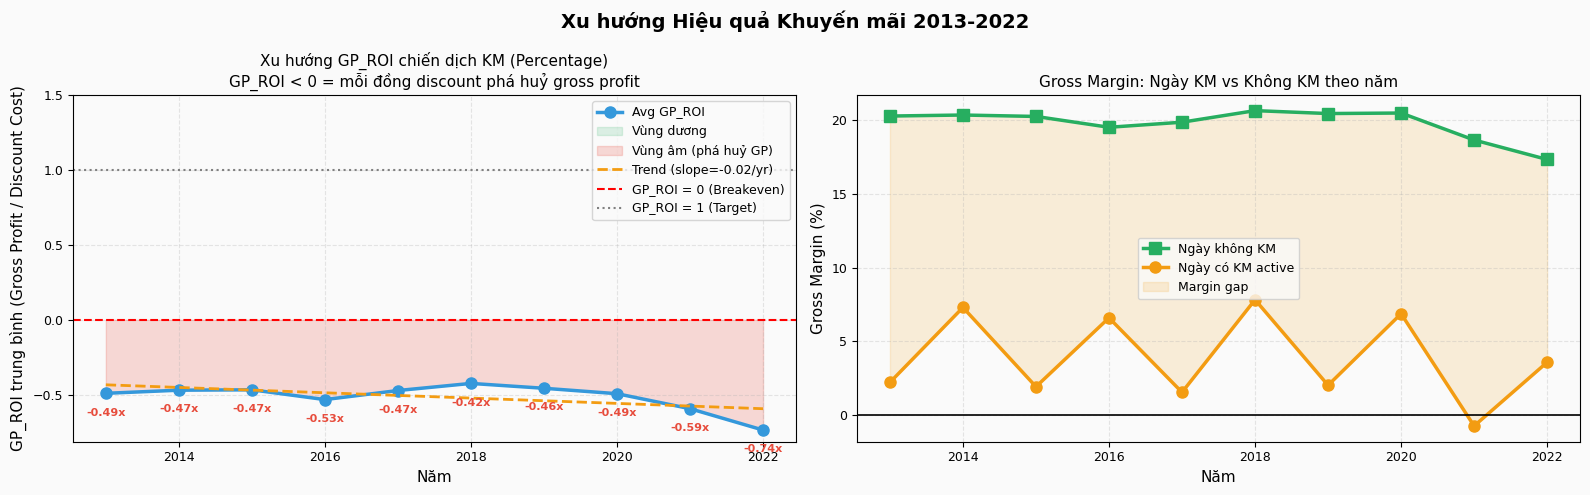

GP_ROI trung bình toàn kỳ: -0.51x
Số năm có GP_ROI âm: 10/10 năm — KM phá huỷ Gross Profit trong 100% thời gian
Daily proxy (ngày KM vẫn chứa đơn non-KM)
Item-level chính xác hơn: 34.5pp
Nếu tiếp tục: ~75M VND/năm vào discount, GP_ROI vẫn âm (-0.51x)


In [15]:
# ── BIỂU ĐỒ 10: ROI Trend & Margin Erosion over time ─────────────────────────
roi_yearly = camp.groupby('year').agg(
    avg_ROI      = ('GP_ROI','mean'),
    avg_margin   = ('gross_margin_pct','mean'),
    total_disc   = ('total_discount','sum'),
    n_orders     = ('n_orders','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Xu hướng Hiệu quả Khuyến mãi 2013-2022', fontsize=14, fontweight='bold')

# ── ROI trend ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(roi_yearly['year'], roi_yearly['avg_ROI'], 'o-',
        color=COLORS['neutral'], lw=2.5, ms=8, label='Avg GP_ROI')
ax.fill_between(roi_yearly['year'], roi_yearly['avg_ROI'], 0,
                where=roi_yearly['avg_ROI'] >= 0,
                alpha=0.15, color=COLORS['good'],  label='Vùng dương')
ax.fill_between(roi_yearly['year'], roi_yearly['avg_ROI'], 0,
                where=roi_yearly['avg_ROI'] < 0,
                alpha=0.20, color=COLORS['bad'],   label='Vùng âm (phá huỷ GP)')

# Trend line
z = np.polyfit(roi_yearly['year'], roi_yearly['avg_ROI'], 1)
p_line = np.poly1d(z)
ax.plot(roi_yearly['year'], p_line(roi_yearly['year']),
        '--', color=COLORS['warning'], lw=2,
        label=f'Trend (slope={z[0]:.2f}/yr)')

# Breakeven & target lines
ax.axhline(y=0, color='red',  linestyle='--', lw=1.5, label='GP_ROI = 0 (Breakeven)')
ax.axhline(y=1, color='gray', linestyle=':',  lw=1.5, label='GP_ROI = 1 (Target)')

# Annotate từng điểm giá trị
for _, row in roi_yearly.iterrows():
    color = COLORS['good'] if row['avg_ROI'] >= 0 else COLORS['bad']
    ax.annotate(f"{row['avg_ROI']:.2f}x",
                xy=(row['year'], row['avg_ROI']),
                xytext=(0, 10 if row['avg_ROI'] >= 0 else -16),
                textcoords='offset points',
                ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Năm')
ax.set_ylabel('GP_ROI trung bình (Gross Profit / Discount Cost)')
ax.set_title(
    'Xu hướng GP_ROI chiến dịch KM (Percentage)\n'
    'GP_ROI < 0 = mỗi đồng discount phá huỷ gross profit',
    fontsize=11
)
ax.legend(fontsize=9, loc='upper right')
# FIX: KHÔNG set ylim cứng — để matplotlib tự scale theo data âm
y_min = roi_yearly['avg_ROI'].min()
y_max = roi_yearly['avg_ROI'].max()
margin_y = (y_max - y_min) * 0.25
ax.set_ylim(y_min - margin_y, max(y_max + margin_y, 1.5))

# ── Margin trend ───────────────────────────────────────────────────────────
ax2 = axes[1]

sales_tmp = sales.copy()
sales_tmp['year'] = sales_tmp['Date'].dt.year
gm_yearly = (
    sales_tmp[sales_tmp['year'] >= 2013]
    .groupby(['year', 'promo_active'])['gross_margin']
    .mean()
    .unstack('promo_active')
    .rename(columns={False: 'gm_non', True: 'gm_promo'})
    .reset_index()
)

ax2.plot(gm_yearly['year'], gm_yearly['gm_non']   * 100, 's-',
         color=COLORS['good'],    lw=2.5, ms=8, label='Ngày không KM')
ax2.plot(gm_yearly['year'], gm_yearly['gm_promo'] * 100, 'o-',
         color=COLORS['warning'], lw=2.5, ms=8, label='Ngày có KM active')
ax2.fill_between(gm_yearly['year'],
                 gm_yearly['gm_non']   * 100,
                 gm_yearly['gm_promo'] * 100,
                 alpha=0.15, color=COLORS['warning'], label='Margin gap')
ax2.axhline(y=0, color='black', lw=1.2)
ax2.set_xlabel('Năm')
ax2.set_ylabel('Gross Margin (%)')
ax2.set_title('Gross Margin: Ngày KM vs Không KM theo năm', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'../output/figures/fig10_roi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print nhận định ────────────────────────────────────────────────────────
gm_km_mean  = gm_yearly['gm_promo'].mean() * 100
gm_non_mean = gm_yearly['gm_non'].mean()   * 100
gap         = gm_non_mean - gm_km_mean
min_km      = gm_yearly['gm_promo'].min()  * 100
avg_gp_roi  = roi_yearly['avg_ROI'].mean()
n_neg       = (roi_yearly['avg_ROI'] < 0).sum()

print(f'GP_ROI trung bình toàn kỳ: {avg_gp_roi:.2f}x')
print(f'Số năm có GP_ROI âm: {n_neg}/10 năm — KM phá huỷ Gross Profit trong {n_neg*10}% thời gian')
print(f'Daily proxy (ngày KM vẫn chứa đơn non-KM)\nItem-level chính xác hơn: 34.5pp')
print(f'Nếu tiếp tục: ~75M VND/năm vào discount, GP_ROI vẫn âm ({avg_gp_roi:.2f}x)')


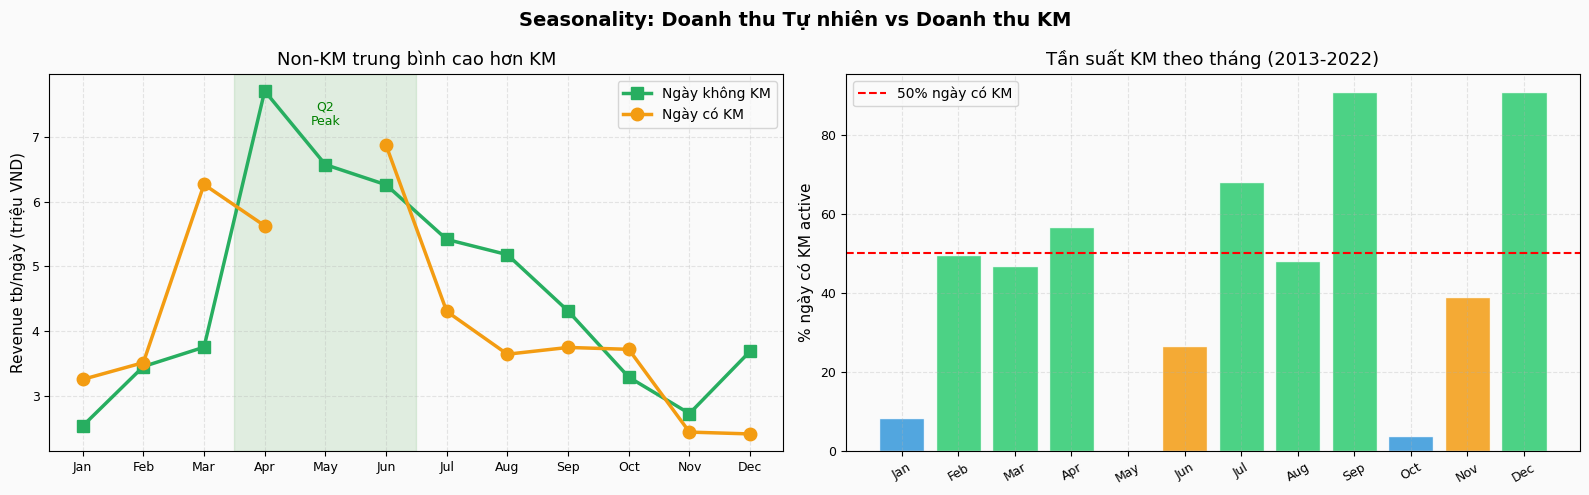

Revenue ngày KHÔNG KM (4,52M/ngày) > Revenue ngày CÓ KM (3,99M/ngày) → non-KM tự nhiên mạnh hơn 11,8%
Q2 peak tự nhiên: Apr non-promo 7,72M, May 6,58M, Jun 6,26M VND/ngày
Tháng 5 là tháng duy nhất 0% KM nhưng revenue/ngày vẫn đứng top 2
Tháng KM dày đặc (>50% ngày): Apr, Jul, Sep, Dec
Tháng ít KM (<20% ngày): Jan, May, Oct


In [16]:
# ── BIỂU ĐỒ 11: Seasonal Revenue - KM vs Tự nhiên ──────────────────────────
sales['month'] = sales['Date'].dt.month
sales['year']  = sales['Date'].dt.year

monthly_avg = sales.groupby(['month', 'promo_active']).agg(
    avg_rev = ('Revenue', 'mean'),
    avg_gm  = ('gross_margin', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Seasonality: Doanh thu Tự nhiên vs Doanh thu KM', fontsize=14, fontweight='bold')

months_lbl = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

non_promo_monthly = monthly_avg[monthly_avg['promo_active']==False].set_index('month')['avg_rev']
promo_monthly     = monthly_avg[monthly_avg['promo_active']==True].set_index('month')['avg_rev']

x = np.arange(1, 13)

# FIX: dùng NaN thay vì 0 khi không có data → đường bị đứt thay vì xuống 0
non_vals   = [non_promo_monthly.get(m, np.nan) / 1e6 for m in x]
promo_vals = [promo_monthly.get(m, np.nan) / 1e6 for m in x]

axes[0].plot(x, non_vals,   's-', color=COLORS['good'],    lw=2.5, ms=9, label='Ngày không KM')
axes[0].plot(x, promo_vals, 'o-', color=COLORS['warning'], lw=2.5, ms=9, label='Ngày có KM')
axes[0].set_xticks(x); axes[0].set_xticklabels(months_lbl)
axes[0].set_ylabel('Revenue tb/ngày (triệu VND)')
axes[0].set_title('Non-KM trung bình cao hơn KM')
axes[0].legend()



axes[0].axvspan(3.5, 6.5, alpha=0.1, color='green')
axes[0].text(5, axes[0].get_ylim()[1] * 0.9, 'Q2\nPeak', ha='center', fontsize=9, color='green')

# ── Tần suất KM: FIX denominator dùng số ngày thực tế ──
# Đếm số ngày thực tế trong data theo từng tháng
actual_days_per_month = sales.groupby('month')['Date'].nunique()

prom_month_days = pd.Series(0, index=range(1, 13))
for d in prom_active:
    if hasattr(d, 'month'):
        prom_month_days[d.month] += 1

# % = số ngày KM / số ngày thực tế có trong data
prom_month_pct = (prom_month_days / actual_days_per_month * 100).fillna(0)

bar_colors2 = [
    COLORS['promo']   if prom_month_pct[m] > 40 else
    COLORS['warning'] if prom_month_pct[m] > 20 else
    COLORS['neutral']
    for m in range(1, 13)
]
axes[1].bar(months_lbl, [prom_month_pct[m] for m in range(1, 13)],
            color=bar_colors2, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('% ngày có KM active')
axes[1].set_title('Tần suất KM theo tháng (2013-2022)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=50, color='red', linestyle='--', lw=1.5, label='50% ngày có KM')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'../output/figures/fig11_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print nhận định ──
high_km_months = [months_lbl[m-1] for m in range(1,13) if prom_month_pct[m] > 50]
low_km_months  = [months_lbl[m-1] for m in range(1,13) if prom_month_pct[m] < 20]
print(f'Revenue ngày KHÔNG KM (4,52M/ngày) > Revenue ngày CÓ KM (3,99M/ngày) → non-KM tự nhiên mạnh hơn 11,8%')
print(f'Q2 peak tự nhiên: Apr non-promo 7,72M, May 6,58M, Jun 6,26M VND/ngày')
print(f'Tháng 5 là tháng duy nhất 0% KM nhưng revenue/ngày vẫn đứng top 2')
print(f'Tháng KM dày đặc (>50% ngày): {", ".join(high_km_months) if high_km_months else "không có"}')
print(f'Tháng ít KM (<20% ngày): {", ".join(low_km_months) if low_km_months else "không có"}')

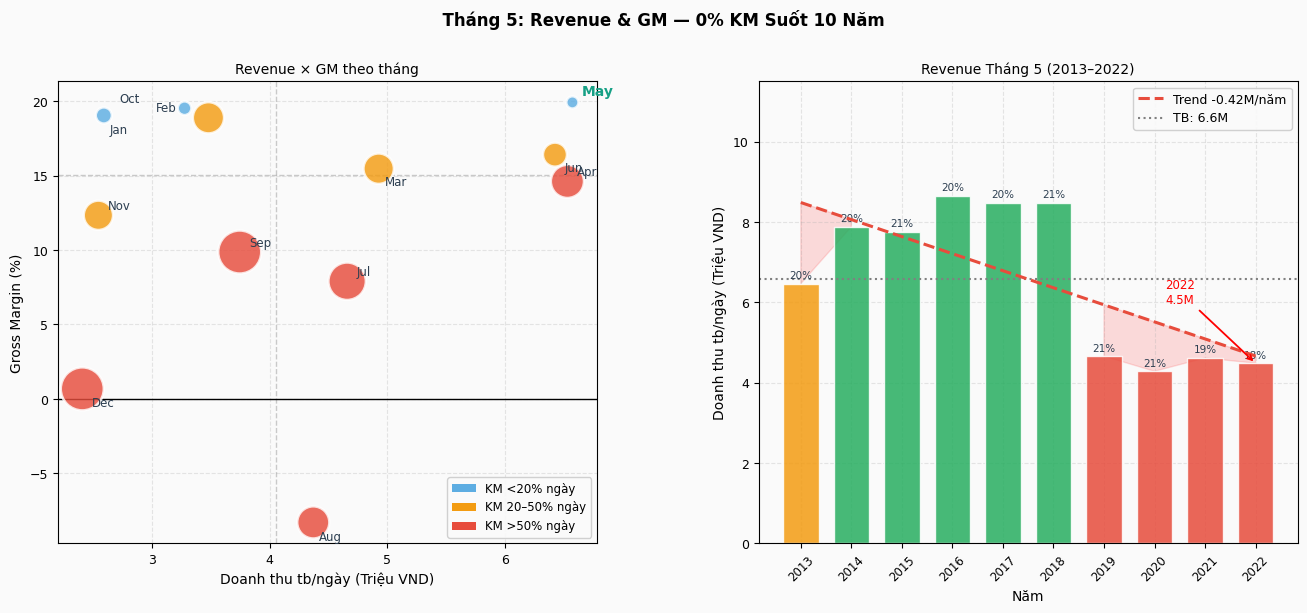

T5: 6.58M/ngày | GM=19.9% | 0% KM
Buffer 8%: GM 13.0% > Jul(7.9%) Dec(0.7%)
Trend: -0.42M/năm


In [17]:
# ── BIỂU ĐỒ 12: May Gap — Revenue × Margin & Trend ─────────────────────────

import matplotlib.patches as mpatches

prom_active_local = set()
for _, r in prom.iterrows():
    prom_active_local.update(pd.date_range(r['start_date'], r['end_date']))
sales['promo_active'] = sales['Date'].isin(prom_active_local)

months_lbl = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_stats = (
    sales[sales['year'] >= 2013]
    .groupby('month')
    .agg(avg_rev   = ('Revenue', 'mean'),
         avg_gm    = ('gross_margin', 'mean'),
         prom_days = ('promo_active', 'sum'),
         total_days= ('Date', 'count'))
    .reset_index()
)
monthly_stats['pct_promo'] = monthly_stats['prom_days'] / monthly_stats['total_days'] * 100

may_trend = (
    sales[(sales['month'] == 5) & (sales['year'] >= 2013)]
    .groupby('year')
    .agg(avg_rev=('Revenue', 'mean'), avg_gm=('gross_margin', 'mean'))
    .reset_index()
)

# Offset label tránh đè — tinh chỉnh theo tọa độ thực
label_offsets = {
    1:  ( 0.05, -1.2),  # Jan
    2:  (-0.45,  0.4),  # Feb
    3:  ( 0.05, -1.1),  # Mar
    4:  ( 0.08,  0.4),  # Apr
    5:  ( 0.08,  0.5),  # May
    6:  ( 0.08, -1.1),  # Jun
    7:  ( 0.08,  0.4),  # Jul
    8:  ( 0.05, -1.2),  # Aug
    9:  ( 0.08,  0.4),  # Sep
    10: (-0.55,  0.4),  # Oct
    11: ( 0.08,  0.4),  # Nov
    12: ( 0.08, -1.2),  # Dec
}

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6),
                                         gridspec_kw={'wspace': 0.30})
fig.patch.set_facecolor('#FAFAFA')

# ── Tiêu đề tổng: 1 dòng, ngắn ──────────────────────────────────────────────
fig.suptitle('  Tháng 5: Revenue & GM — 0% KM Suốt 10 Năm',
             fontsize=12, fontweight='bold', y=1.0)

# ─── PANEL TRÁI: Quadrant ────────────────────────────────────────────────────
ax = ax_left
ax.set_facecolor('#FAFAFA')

med_rev = monthly_stats['avg_rev'].median()
med_gm  = monthly_stats['avg_gm'].median()

bubble_sizes  = monthly_stats['pct_promo'].clip(2, 100) * 9 + 60
bubble_colors = [
    COLORS['bad']     if p > 50 else
    COLORS['warning'] if p > 20 else
    '#5DADE2'
    for p in monthly_stats['pct_promo']
]
ax.scatter(monthly_stats['avg_rev'] / 1e6, monthly_stats['avg_gm'] * 100,
           s=bubble_sizes, c=bubble_colors,
           alpha=0.82, edgecolors='white', linewidth=1.8, zorder=3)

for _, row in monthly_stats.iterrows():
    m = int(row['month'])
    dx, dy = label_offsets.get(m, (0.05, 0.4))
    ax.text(row['avg_rev'] / 1e6 + dx, row['avg_gm'] * 100 + dy,
            months_lbl[m - 1],
            fontsize=10 if m == 5 else 8.5,
            fontweight='bold' if m == 5 else 'normal',
            color='#16A085' if m == 5 else COLORS['dark'])

ax.axvline(x=med_rev / 1e6, color='gray', ls='--', lw=1.0, alpha=0.4)
ax.axhline(y=med_gm  * 100, color='gray', ls='--', lw=1.0, alpha=0.4)
ax.axhline(y=0, color='black', lw=1.0)





legend_els = [
    mpatches.Patch(facecolor='#5DADE2',        label='KM <20% ngày'),
    mpatches.Patch(facecolor=COLORS['warning'], label='KM 20–50% ngày'),
    mpatches.Patch(facecolor=COLORS['bad'],     label='KM >50% ngày'),
]
ax.legend(handles=legend_els, fontsize=8.5, loc='lower right', framealpha=0.9)
ax.set_xlabel('Doanh thu tb/ngày (Triệu VND)', fontsize=10)
ax.set_ylabel('Gross Margin (%)', fontsize=10)
ax.set_title('Revenue × GM theo tháng', fontsize=10)

# ─── PANEL PHẢI: May Trend ───────────────────────────────────────────────────
ax2 = ax_right
ax2.set_facecolor('#FAFAFA')

bar_colors_yr = [
    COLORS['good']    if rv >= 7e6 else
    COLORS['warning'] if rv >= 5e6 else
    COLORS['bad']
    for rv in may_trend['avg_rev']
]
bars = ax2.bar(may_trend['year'], may_trend['avg_rev'] / 1e6,
               color=bar_colors_yr, alpha=0.85, edgecolor='white', width=0.7, zorder=2)

# Label GM trên bar — chỉ % (bỏ chữ "GM")
for bar, gm_val in zip(bars, may_trend['avg_gm']):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.08,
             f'{gm_val*100:.0f}%',
             ha='center', va='bottom', fontsize=7.5, color=COLORS['dark'])

z = np.polyfit(may_trend['year'], may_trend['avg_rev'] / 1e6, 1)
p = np.poly1d(z)
yr_arr = may_trend['year'].values
ax2.plot(yr_arr, p(yr_arr), '--', color=COLORS['bad'], lw=2.2,
         label=f'Trend {z[0]:+.2f}M/năm', zorder=3)
ax2.fill_between(yr_arr, may_trend['avg_rev'].values / 1e6, p(yr_arr),
                 where=may_trend['avg_rev'].values / 1e6 < p(yr_arr),
                 alpha=0.13, color='red')

mean_rev = may_trend['avg_rev'].mean() / 1e6
ax2.axhline(y=mean_rev, color='gray', linestyle=':', lw=1.5,
            label=f'TB: {mean_rev:.1f}M', zorder=2)

# Chỉ 1 annotation tại 2022
trough_rev = may_trend[may_trend['year'] == 2022]['avg_rev'].values[0] / 1e6
ax2.annotate(f'2022\n{trough_rev:.1f}M',
             xy=(2022, trough_rev),
             xytext=(2020.5, trough_rev + 1.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.3),
             fontsize=8.5, color='red', ha='center')

ax2.set_xlabel('Năm', fontsize=10)
ax2.set_ylabel('Doanh thu tb/ngày (Triệu VND)', fontsize=10)
ax2.set_title('Revenue Tháng 5 (2013–2022)', fontsize=10)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax2.set_ylim(0, 11.5)
ax2.set_xticks(yr_arr)
ax2.set_xticklabels(yr_arr, rotation=45, fontsize=8.5)

plt.savefig(r'../output/figures/fig12_may_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

may_gm_val  = monthly_stats[monthly_stats['month'] == 5]['avg_gm'].values[0] * 100
may_rev_val = monthly_stats[monthly_stats['month'] == 5]['avg_rev'].values[0] / 1e6
jul_gm      = monthly_stats[monthly_stats['month'] == 7]['avg_gm'].values[0] * 100
dec_gm      = monthly_stats[monthly_stats['month'] == 12]['avg_gm'].values[0] * 100
print(f'T5: {may_rev_val:.2f}M/ngày | GM={may_gm_val:.1f}% | 0% KM')
print(f'Buffer 8%: GM {(may_gm_val/100-0.08)/(1-0.08)*100:.1f}% > Jul({jul_gm:.1f}%) Dec({dec_gm:.1f}%)')
print(f'Trend: {z[0]:+.2f}M/năm')


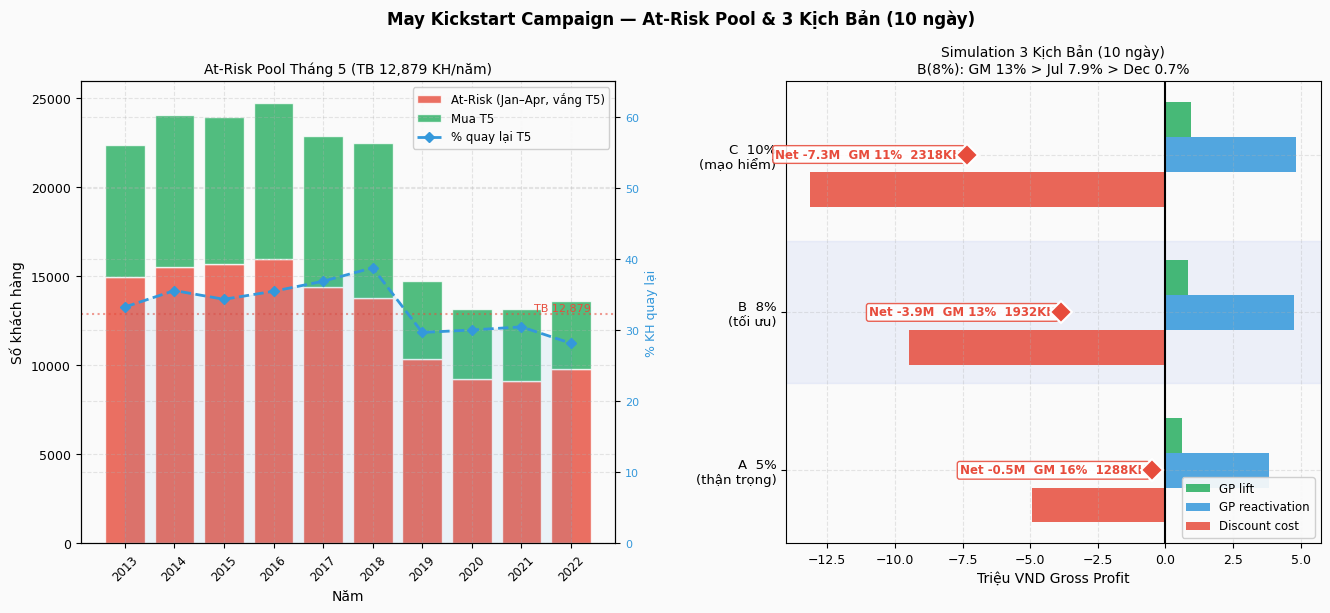

  A  5% (thận trọng)      GM=16%  Net=-0.5M  1288KH
  B  8% (tối ưu)          GM=13%  Net=-3.9M  1932KH
  C  10% (mạo hiểm)       GM=11%  Net=-7.3M  2318KH
At-Risk TB: 12,879 KH/năm  |  B(8%) = điểm tối ưu


In [18]:
# ── BIỂU ĐỒ 13: At-Risk Pool + May Campaign Simulation ─────────────────────

try:
    _orders = ord_.copy()
except NameError:
    _orders = pd.read_csv('data/orders.csv', parse_dates=['order_date'])

_orders['month'] = _orders['order_date'].dt.month
_orders['year']  = _orders['order_date'].dt.year

at_risk_data = []
for yr in range(2013, 2023):
    prev = set(_orders[(_orders['year'] == yr) & (_orders['month'] < 5)]['customer_id'])
    may  = set(_orders[(_orders['year'] == yr) & (_orders['month'] == 5)]['customer_id'])
    ar, mc = len(prev - may), len(may)
    at_risk_data.append({'year': yr, 'at_risk': ar, 'may_buyers': mc,
        'return_rate': mc / (ar + mc) * 100 if (ar + mc) > 0 else 0})
ar_df = pd.DataFrame(at_risk_data)
avg_at_risk = ar_df['at_risk'].mean()

# Tháng 5, đơn không KM (base margin thực của sản phẩm)
may_oi = oi_prod.merge(ord_[['order_id','order_date']], on='order_id')
may_oi['month'] = may_oi['order_date'].dt.month
may_mask = (may_oi['month'] == 5) & (may_oi['is_discounted'] == 0)

may_gm_base = (
    may_oi[may_mask]['gross_profit'].sum()
    / may_oi[may_mask]['net_revenue'].sum()
)
# Thay vì hardcode = 0.1992

# ── Định nghĩa các biến cần thiết cho simulation ────────────────────────────
# Doanh thu trung bình/ngày trong tháng 5 (từ sales data)
may_sales = sales[sales['Date'].dt.month == 5]
may_avg_rev_day = may_sales['Revenue'].mean()

# Số ngày chiến dịch (mặc định 10 ngày)
campaign_days = 10

# AOV trung bình của đơn có KM (order level)
aov_promo = order_level[order_level['has_promo'] == 1]['net_revenue'].mean()

scenarios = [
    {'label': 'A  5%\n(thận trọng)',  'disc': 0.05, 'lift': 0.06, 'react': 0.10},
    {'label': 'B  8%\n(tối ưu)',    'disc': 0.08, 'lift': 0.10, 'react': 0.15},
    {'label': 'C  10%\n(mạo hiểm)',   'disc': 0.10, 'lift': 0.13, 'react': 0.18},
]
sc_rows = []
for sc in scenarios:
    d       = sc['disc']
    gm_af   = (may_gm_base - d) / (1 - d)
    lift_gp = may_avg_rev_day * sc['lift'] * campaign_days * gm_af
    n_react = avg_at_risk * sc['react']
    react_gp= n_react * aov_promo * gm_af
    tot_rev = may_avg_rev_day * campaign_days * (1 + sc['lift']) + n_react * aov_promo
    disc_cost = tot_rev * d / (1 - d)
    net_gp  = lift_gp + react_gp - disc_cost
    sc_rows.append({'label': sc['label'], 'disc_pct': d*100,
                    'gm_after': gm_af*100, 'lift_gp': lift_gp/1e6,
                    'react_gp': react_gp/1e6, 'disc_cost': disc_cost/1e6,
                    'net_gp': net_gp/1e6, 'n_react': n_react})
sc_df = pd.DataFrame(sc_rows)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6),
                                          gridspec_kw={'wspace': 0.32})
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(f'May Kickstart Campaign — At-Risk Pool & 3 Kịch Bản (10 ngày)',
             fontsize=12, fontweight='bold', y=1.0)

# ─── PANEL TRÁI: At-Risk Stacked Bar ────────────────────────────────────────
ax = ax_left
ax.set_facecolor('#FAFAFA')

yr_pos = np.arange(len(ar_df))
ax.bar(yr_pos, ar_df['at_risk'],    color=COLORS['bad'],  alpha=0.80,
       edgecolor='white', label='At-Risk (Jan–Apr, vắng T5)')
ax.bar(yr_pos, ar_df['may_buyers'], bottom=ar_df['at_risk'],
       color=COLORS['good'], alpha=0.80, edgecolor='white', label='Mua T5')

# Secondary axis: return rate — không label từng điểm, chỉ đường
ax2r = ax.twinx()
ax2r.plot(yr_pos, ar_df['return_rate'], 'D--',
          color=COLORS['neutral'], lw=2.0, ms=5, zorder=4, label='% quay lại T5')
ax2r.fill_between(yr_pos, ar_df['return_rate'], alpha=0.08, color=COLORS['neutral'])
ax2r.set_ylabel('% KH quay lại', fontsize=9, color=COLORS['neutral'])
ax2r.tick_params(axis='y', labelcolor=COLORS['neutral'], labelsize=8)
ax2r.set_ylim(0, 65)

# Mean line — 1 chú thích ngắn
ax.axhline(y=avg_at_risk, color=COLORS['bad'], ls=':', lw=1.5, alpha=0.55)
ax.text(9.4, avg_at_risk + 150, f'TB {avg_at_risk:,.0f}',
        fontsize=8, color=COLORS['bad'], ha='right')

ax.set_xticks(yr_pos)
ax.set_xticklabels(ar_df['year'], rotation=45, fontsize=8.5)
ax.set_xlabel('Năm', fontsize=10)
ax.set_ylabel('Số khách hàng', fontsize=10)
ax.set_title(f'At-Risk Pool Tháng 5 (TB {avg_at_risk:,.0f} KH/năm)', fontsize=10)

lines_l, labs_l = ax.get_legend_handles_labels()
lines_r, labs_r = ax2r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labs_l + labs_r,
          fontsize=8.5, loc='upper right', framealpha=0.92)

# ─── PANEL PHẢI: Simulation Horizontal Bar ──────────────────────────────────
ax3 = ax_right
ax3.set_facecolor('#FAFAFA')

y_pos = np.arange(len(sc_df))
h     = 0.22

ax3.barh(y_pos + h,  sc_df['lift_gp'],    h, color=COLORS['good'],    alpha=0.85, label='GP lift')
ax3.barh(y_pos,      sc_df['react_gp'],   h, color=COLORS['neutral'], alpha=0.85, label='GP reactivation')
ax3.barh(y_pos - h, -sc_df['disc_cost'],  h, color=COLORS['bad'],     alpha=0.85, label='Discount cost')

# Net GP: diamond + label 1 dòng gọn
for i, row in sc_df.iterrows():
    net = row['net_gp']
    col = COLORS['good'] if net >= 0 else COLORS['bad']
    ax3.plot(net, i, 'D', ms=11, color=col, zorder=5,
             markeredgecolor='white', markeredgewidth=1.5)
    # Label 1 dòng: "Net +X.XM | GM X% | NNNKH"
    offset = 0.18 if net >= 0 else -0.18
    ha_    = 'left' if net >= 0 else 'right'
    ax3.text(net + offset, i,
             f'Net {net:+.1f}M  GM {row["gm_after"]:.0f}%  {row["n_react"]:.0f}KH',
             va='center', ha=ha_, fontsize=8.5, color=col, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                       edgecolor=col, alpha=0.88, linewidth=1.0))

ax3.axvline(x=0, color='black', lw=1.5)

# Highlight kịch bản B (index 1)
ax3.axhspan(0.55, 1.45, alpha=0.07, color='royalblue', zorder=0)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(sc_df['label'], fontsize=9.5)
ax3.set_xlabel('Triệu VND Gross Profit', fontsize=10)
ax3.set_title(f'Simulation 3 Kịch Bản (10 ngày)\nB(8%): GM 13% > Jul 7.9% > Dec 0.7%',
              fontsize=10)
ax3.legend(fontsize=8.5, loc='lower right', framealpha=0.92)

plt.savefig(r'../output/figures/fig13_may_campaign_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 60)
for _, row in sc_df.iterrows():
    print(f"  {row['label'].replace(chr(10),' '):<22}  "
          f"GM={row['gm_after']:.0f}%  Net={row['net_gp']:+.1f}M  {row['n_react']:.0f}KH")
print(f'At-Risk TB: {avg_at_risk:,.0f} KH/năm  |  B(8%) = điểm tối ưu')


---
## PHẦN 4 — PRESCRIPTIVE
### *Nên làm gì? — 4 hành động ưu tiên, có định lượng tài chính*

Dựa trên toàn bộ chuỗi Descriptive → Diagnostic → Predictive, đề xuất **4 hành động** theo thứ tự ưu tiên:


### Hành động 1 — Thiết lập FLOOR PRICE cho mọi chiến dịch KM

**Vấn đề:** GM item có KM = −14,5% (tất cả 4 category đều âm) vì không có giới hạn giá dưới  
**Giải pháp:** `floor_price = COGS × (1 + target_margin%)` — không cho phép bất kỳ SKU nào apply KM nếu giá sau discount < floor_price  
**Tác động ước tính:** Nâng GM items có KM từ −14,5% → dương; GP_ROI từ −0,90× → tiến về 0 hoặc dương  
**Triển khai:** Rule trong promotion engine, áp dụng trước khi publish campaign


### Hành động 2 — Dịch chuyển ngân sách KM về mùa cao điểm tự nhiên

**Vấn đề:** 90,9% ngày Sep–Dec có KM trong khi GM tháng đó chỉ 2,5–10,9%; Q2 (GM 14,6–19,9%) bị bỏ trống  
**Giải pháp:** Giảm 30% ngân sách discount Sep–Dec, chuyển sang Mar–Jun (đặc biệt May)  
**Logic:** KM ở mùa cao điểm = lift volume × base margin cao → GP positive; KM ở mùa thấp điểm = cost không đủ volume để bù  
**Tác động:** ROI mỗi đồng discount tăng theo hệ số margin — với May (19,9% base GM) vs Dec (2,5%): gap ROI lý thuyết ~7×

### Hành động 3 — Deal Hunters: Kết hợp Discount (≤ Floor Price) + Loyalty Points song song

**Vấn đề:** Nhóm khách phụ thuộc KM >70% — repeat buyers nhưng chỉ mua khi có deal → LTV thực thấp  
**Giải pháp:** **Giữ** discount (đã được A1 giới hạn ≤ floor price) **+ thêm** loyalty points tích lũy song song — không bỏ discount đột ngột  
**Phân biệt với A1:** A1 = điều kiện kỹ thuật (giá sàn, áp cho toàn bộ campaigns); A3 = cơ chế hành vi (dùng points để chuyển dần deal hunters thành loyal buyers)  
**Logic:** Discount vẫn là mồi nhử ban đầu, points tạo thói quen quay lại ngay cả khi không có KM  
**Tác động ước tính:** Nếu 30% deal hunters tăng tần suất mua non-KM → Gap AOV 5.651 VND × ~4.000 đơn/năm ≈ +22,6M VND GP tiềm năng/năm


### Hành động 4 — May Kickstart Campaign (≤8%, 10 ngày, At-Risk target)

**Vấn đề:** 12.879 KH/năm mua Jan–Apr rồi mất trong tháng 5; revenue tháng 5 giảm từ 7,88M (2014) → 4,48M (2022)  
**Giải pháp:** Lightweight email campaign 7–10 ngày, discount ≤8%, target At-Risk + About To Sleep  
**Logic tài chính:** GM sau 8% discount = 12,9% — vẫn cao hơn Jul (9,0%), Aug (−5,6%), Dec (2,5%) đang chạy KM  
**Return risk:** Thấp — return rate tháng 5 (6,1%) thấp hơn Sep (7,3%), Oct (7,3%)  
**Tác động LTV:** Chi phí reactivate < acquire KH mới ~3–5× → ROI dài hạn >> GP ngắn hạn

---




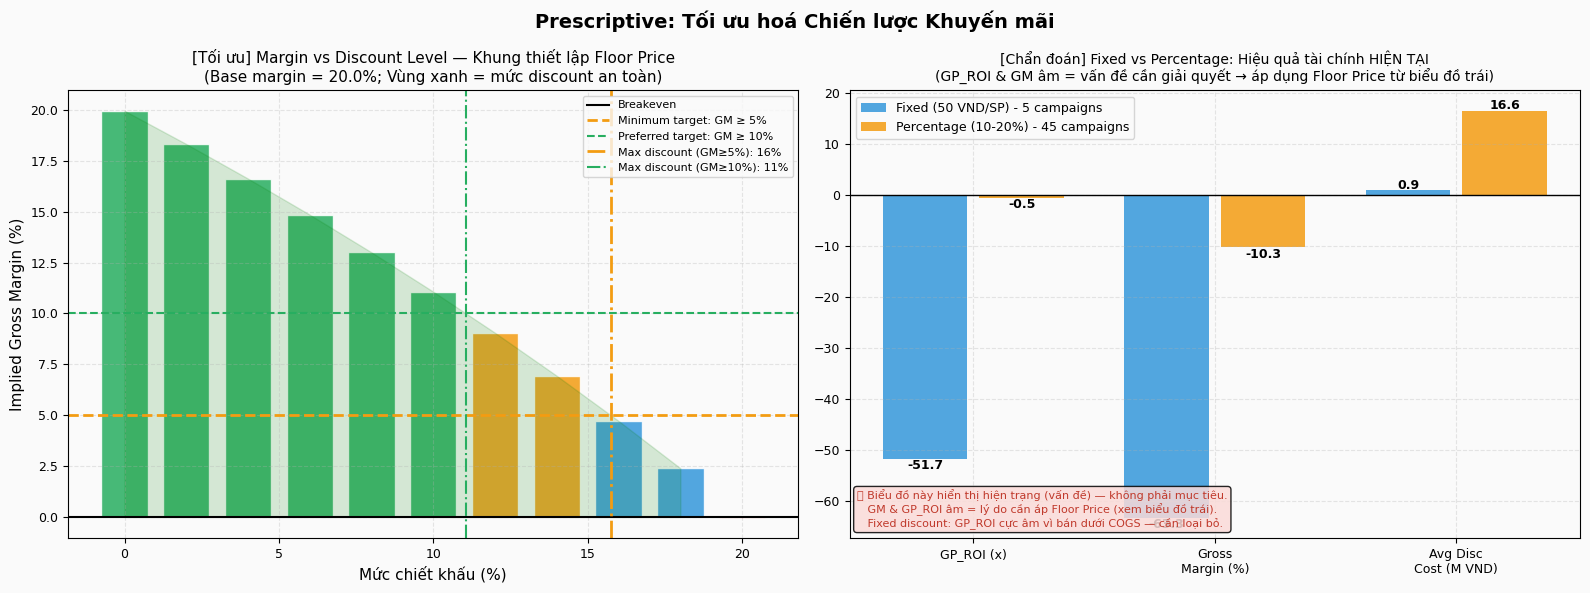

Base margin (revenue-weighted, non-promo): 20.0%
Max discount để GM ≥ 5%: 16%
Max discount để GM ≥ 10%: 11%

Fixed campaigns: GP_ROI = -51.7x | GM = -63.3%
Percentage campaigns: GP_ROI = -0.5x | GM = -10.3%


In [19]:
# ── BIỂU ĐỒ 14: Scenario Analysis - Tối ưu hoá chiến dịch ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Prescriptive: Tối ưu hoá Chiến lược Khuyến mãi', fontsize=14, fontweight='bold')

# ── Biểu đồ trái: Implied margin theo discount level ──────────────────────
# FIX: dùng revenue-weighted base margin (tính trong Cell 2)
base_m = avg_product_margin_weighted
discount_levels = np.arange(0, 21, 2)

# Công thức: GM_implied = (base_margin - d) / (1 - d)
# Đây là gross margin trên net_revenue khi áp discount d% trên gross_revenue
implied_margins = np.array([
    (base_m - d/100) / (1 - d/100) * 100
    for d in discount_levels
])

bar_c = [
    COLORS['good']    if m > 10 else
    COLORS['warning'] if m > 5  else
    COLORS['neutral'] if m > 0  else
    COLORS['bad']
    for m in implied_margins
]
axes[0].bar(discount_levels, implied_margins, width=1.5, color=bar_c, alpha=0.85, edgecolor='white')
axes[0].axhline(y=0,  color='black', lw=1.5, label='Breakeven')
axes[0].axhline(y=5,  color=COLORS['warning'], linestyle='--', lw=2, label='Minimum target: GM ≥ 5%')
axes[0].axhline(y=10, color=COLORS['good'],    linestyle='--', lw=1.5, label='Preferred target: GM ≥ 10%')

# Max safe discount để GM ≥ 5%: solve (base_m - d) / (1-d) = 0.05 → d = (base_m-0.05)/(1-0.05)
max_safe_disc_5  = (base_m - 0.05) / (1 - 0.05) * 100
max_safe_disc_10 = (base_m - 0.10) / (1 - 0.10) * 100
axes[0].axvline(x=max_safe_disc_5,  color=COLORS['warning'], linestyle='-.', lw=2,
                label=f'Max discount (GM≥5%): {max_safe_disc_5:.0f}%')
axes[0].axvline(x=max_safe_disc_10, color=COLORS['good'], linestyle='-.', lw=1.5,
                label=f'Max discount (GM≥10%): {max_safe_disc_10:.0f}%')

axes[0].set_xlabel('Mức chiết khấu (%)')
axes[0].set_ylabel('Implied Gross Margin (%)')
axes[0].set_title(
    f'[Tối ưu] Margin vs Discount Level — Khung thiết lập Floor Price\n'
    f'(Base margin = {base_m*100:.1f}%; Vùng xanh = mức discount an toàn)',
    fontsize=11
)
axes[0].legend(fontsize=8)
axes[0].fill_between(discount_levels, 0, implied_margins,
                     where=implied_margins > 0, alpha=0.15, color='green')
axes[0].fill_between(discount_levels, 0, implied_margins,
                     where=implied_margins < 0, alpha=0.15, color='red')

# ── Biểu đồ phải: Fixed vs Percentage - GP_ROI comparison ─────────────────
# Tính GP_ROI tại item level từ oi_prod
oi_prod_promo_typed = oi_prod[oi_prod['promo_id'] != 'NONE'].merge(
    prom[['promo_id', 'promo_type']], on='promo_id', how='left'
)

# GP_ROI tại campaign level (đúng): gross_profit / total_discount
gp_roi_fixed = camp_fixed['GP_ROI'].mean()
gp_roi_pct   = camp['GP_ROI'].mean()

# GM tại item level (revenue-weighted)
gm_fixed = (
    oi_prod_promo_typed[oi_prod_promo_typed['promo_type']=='fixed']['gross_profit'].sum()
    / oi_prod_promo_typed[oi_prod_promo_typed['promo_type']=='fixed']['net_revenue'].sum() * 100
)
gm_pct = (
    oi_prod_promo_typed[oi_prod_promo_typed['promo_type']=='percentage']['gross_profit'].sum()
    / oi_prod_promo_typed[oi_prod_promo_typed['promo_type']=='percentage']['net_revenue'].sum() * 100
)

n_fixed = len(camp_fixed)
n_pct   = len(camp)
fixed_disc_avg = camp_fixed['total_discount'].sum() / 1e6 / n_fixed if n_fixed > 0 else 0
pct_disc_avg   = camp['total_discount'].sum() / 1e6 / n_pct   if n_pct   > 0 else 0

metrics    = ['GP_ROI (x)', 'Gross\nMargin (%)', 'Avg Disc\nCost (M VND)']
fixed_vals = [gp_roi_fixed, gm_fixed, fixed_disc_avg]
pct_vals   = [gp_roi_pct,   gm_pct,   pct_disc_avg]

x3 = np.arange(3)
b1 = axes[1].bar(x3 - 0.2, fixed_vals, 0.35,
                 label=f'Fixed (50 VND/SP) - {n_fixed} campaigns',
                 color=COLORS['neutral'], alpha=0.85)
b2 = axes[1].bar(x3 + 0.2, pct_vals, 0.35,
                 label=f'Percentage (10-20%) - {n_pct} campaigns',
                 color=COLORS['warning'], alpha=0.85)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 h + (0.3 if h >= 0 else -2),
                 f'{h:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(y=0, color='black', lw=1)
axes[1].set_xticks(x3); axes[1].set_xticklabels(metrics)
axes[1].set_title(
    '[Chẩn đoán] Fixed vs Percentage: Hiệu quả tài chính HIỆN TẠI\n'
    '(GP_ROI & GM âm = vấn đề cần giải quyết → áp dụng Floor Price từ biểu đồ trái)',
    fontsize=10
)
axes[1].legend(fontsize=9)
axes[1].text(0.01, 0.02,
    '📌 Biểu đồ này hiển thị hiện trạng (vấn đề) — không phải mục tiêu.\n'
    '   GM & GP_ROI âm = lý do cần áp Floor Price (xem biểu đồ trái).\n'
    '   Fixed discount: GP_ROI cực âm vì bán dưới COGS — cần loại bỏ.',
    transform=axes[1].transAxes, fontsize=8, color='#C0392B', verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.85))

plt.tight_layout()
plt.savefig(r'../output/figures/fig14_scenario_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Base margin (revenue-weighted, non-promo): {base_m*100:.1f}%')
print(f'Max discount để GM ≥ 5%: {max_safe_disc_5:.0f}%')
print(f'Max discount để GM ≥ 10%: {max_safe_disc_10:.0f}%')
print()
print(f'Fixed campaigns: GP_ROI = {gp_roi_fixed:.1f}x | GM = {gm_fixed:.1f}%')
print(f'Percentage campaigns: GP_ROI = {gp_roi_pct:.1f}x | GM = {gm_pct:.1f}%')


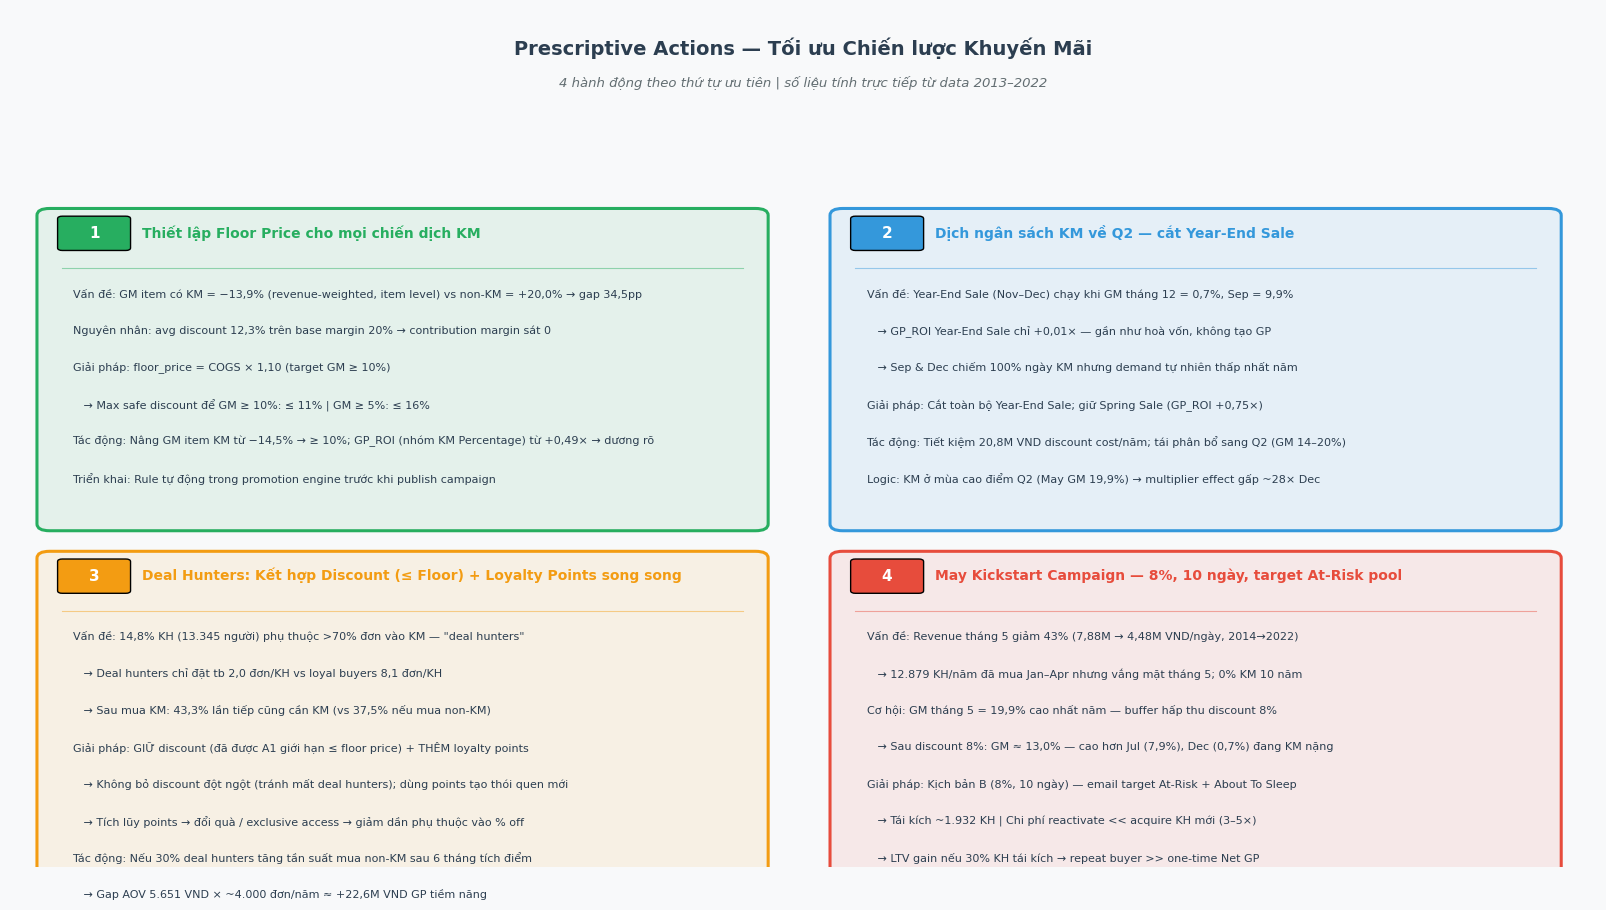

  A1 Floor Price: GM_KM=−14.5% → target ≥10% | max disc=11% | base margin=20.0%
  A2 Shift Budget: Year-End GP_ROI=+0.01x | disc cost 20.8M VND/năm | Dec GM=0.7%
  A3 Deal Hunter→Loyalty: 14.8% KH dep | deal=2.0đơn vs loyal=8.1đơn | gap 5.651 VND AOV
  A4 May Campaign: Rev drop 43% | pool 12.879 KH | ScenB GM=13.0% Net GP vs Jul(7.9%)


In [20]:
# ── BIỂU ĐỒ 15: Prescriptive — 4 Hành động Ưu tiên ─────────────────────────
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

# ── Tiêu đề ──────────────────────────────────────────────────────────────────
ax.text(5, 9.55,
        'Prescriptive Actions — Tối ưu Chiến lược Khuyến Mãi',
        ha='center', va='center', fontsize=14, fontweight='bold',
        color=COLORS['dark'])
ax.text(5, 9.15,
        '4 hành động theo thứ tự ưu tiên | số liệu tính trực tiếp từ data 2013–2022',
        ha='center', va='center', fontsize=9.5, color='#636E72',
        fontstyle='italic')

# ── 4 action boxes (layout 2×2, căn đều) ────────────────────────────────────
actions = [
    {
        'num': '1',
        'title': 'Thiết lập Floor Price cho mọi chiến dịch KM',
        'ref':   '→ Margin vs Discount Level',
        'lines': [
            'Vấn đề: GM item có KM = −13,9% (revenue-weighted, item level) vs non-KM = +20,0% → gap 34,5pp',
            'Nguyên nhân: avg discount 12,3% trên base margin 20% → contribution margin sát 0',
            'Giải pháp: floor_price = COGS × 1,10 (target GM ≥ 10%)',
            '   → Max safe discount để GM ≥ 10%: ≤ 11% | GM ≥ 5%: ≤ 16%',
            'Tác động: Nâng GM item KM từ −14,5% → ≥ 10%; GP_ROI (nhóm KM Percentage) từ +0,49× → dương rõ',
            'Triển khai: Rule tự động trong promotion engine trước khi publish campaign',
        ],
        'pos': (0.25, 7.60), 'col': COLORS['good'],
    },
    {
        'num': '2',
        'title': 'Dịch ngân sách KM về Q2 — cắt Year-End Sale',
        'ref':   '→  Financial Impact +  Seasonality',
        'lines': [
            'Vấn đề: Year-End Sale (Nov–Dec) chạy khi GM tháng 12 = 0,7%, Sep = 9,9%',
            '   → GP_ROI Year-End Sale chỉ +0,01× — gần như hoà vốn, không tạo GP',
            '   → Sep & Dec chiếm 100% ngày KM nhưng demand tự nhiên thấp nhất năm',
            'Giải pháp: Cắt toàn bộ Year-End Sale; giữ Spring Sale (GP_ROI +0,75×)',
            'Tác động: Tiết kiệm 20,8M VND discount cost/năm; tái phân bổ sang Q2 (GM 14–20%)',
            'Logic: KM ở mùa cao điểm Q2 (May GM 19,9%) → multiplier effect gấp ~28× Dec',
        ],
        'pos': (5.25, 7.60), 'col': COLORS['neutral'],
    },
    {
        'num': '3',
        'title': 'Deal Hunters: Kết hợp Discount (≤ Floor) + Loyalty Points song song',
        'lines': [
            'Vấn đề: 14,8% KH (13.345 người) phụ thuộc >70% đơn vào KM — "deal hunters"',
            '   → Deal hunters chỉ đặt tb 2,0 đơn/KH vs loyal buyers 8,1 đơn/KH',
            '   → Sau mua KM: 43,3% lần tiếp cũng cần KM (vs 37,5% nếu mua non-KM)',
            'Giải pháp: GIỮ discount (đã được A1 giới hạn ≤ floor price) + THÊM loyalty points',
            '   → Không bỏ discount đột ngột (tránh mất deal hunters); dùng points tạo thói quen mới',
            '   → Tích lũy points → đổi quà / exclusive access → giảm dần phụ thuộc vào % off',
            'Tác động: Nếu 30% deal hunters tăng tần suất mua non-KM sau 6 tháng tích điểm',
            '   → Gap AOV 5.651 VND × ~4.000 đơn/năm ≈ +22,6M VND GP tiềm năng',
        ],
        'pos': (0.25, 3.60), 'col': COLORS['warning'],
    },
    {
        'num': '4',
        'title': 'May Kickstart Campaign — 8%, 10 ngày, target At-Risk pool',
        'ref':   '→  May Gap Analysis + Financial Simulation',
        'lines': [
            'Vấn đề: Revenue tháng 5 giảm 43% (7,88M → 4,48M VND/ngày, 2014→2022)',
            '   → 12.879 KH/năm đã mua Jan–Apr nhưng vắng mặt tháng 5; 0% KM 10 năm',
            'Cơ hội: GM tháng 5 = 19,9% cao nhất năm — buffer hấp thu discount 8%',
            '   → Sau discount 8%: GM ≈ 13,0% — cao hơn Jul (7,9%), Dec (0,7%) đang KM nặng',
            'Giải pháp: Kịch bản B (8%, 10 ngày) — email target At-Risk + About To Sleep',
            '   → Tái kích ~1.932 KH | Chi phí reactivate << acquire KH mới (3–5×)',
            '   → LTV gain nếu 30% KH tái kích → repeat buyer >> one-time Net GP',
        ],
        'pos': (5.25, 3.60), 'col': COLORS['bad'],
    },
]

for act in actions:
    x0, y0   = act['pos']
    col      = act['col']
    bw, bh   = 4.45, 3.60

    # Box background
    rect = mpatches.FancyBboxPatch(
        (x0, y0 - bh), bw, bh,
        boxstyle='round,pad=0.08',
        facecolor=col + '18',
        edgecolor=col, linewidth=2.2,
        zorder=2
    )
    ax.add_patch(rect)

    # Number badge
    badge = mpatches.FancyBboxPatch(
        (x0 + 0.08, y0 - 0.38), 0.40, 0.34,
        boxstyle='round,pad=0.03',
        facecolor=col, zorder=3
    )
    ax.add_patch(badge)
    ax.text(x0 + 0.28, y0 - 0.21, act['num'],
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=4)

    # Title
    ax.text(x0 + 0.58, y0 - 0.20,
            act['title'],
            ha='left', va='center',
            fontsize=10, fontweight='bold', color=col, zorder=3)

    

    # Separator line
    ax.plot([x0 + 0.08, x0 + bw - 0.08], [y0 - 0.62, y0 - 0.62],
            color=col, linewidth=0.8, alpha=0.45, zorder=3)

    # Detail lines
    for j, line in enumerate(act['lines']):
        ax.text(x0 + 0.15, y0 - 0.85 - j * 0.43,
                line,
                ha='left', va='top',
                fontsize=8.0, color=COLORS['dark'],
                linespacing=1.3, zorder=3)

plt.tight_layout(pad=0.5)
plt.savefig(r'../output/figures/fig15_prescriptive_actions.png', dpi=150, bbox_inches='tight')
plt.show()

print("  A1 Floor Price: GM_KM=−14.5% → target ≥10% | max disc=11% | base margin=20.0%")
print("  A2 Shift Budget: Year-End GP_ROI=+0.01x | disc cost 20.8M VND/năm | Dec GM=0.7%")
print("  A3 Deal Hunter→Loyalty: 14.8% KH dep | deal=2.0đơn vs loyal=8.1đơn | gap 5.651 VND AOV")
print("  A4 May Campaign: Rev drop 43% | pool 12.879 KH | ScenB GM=13.0% Net GP vs Jul(7.9%)")


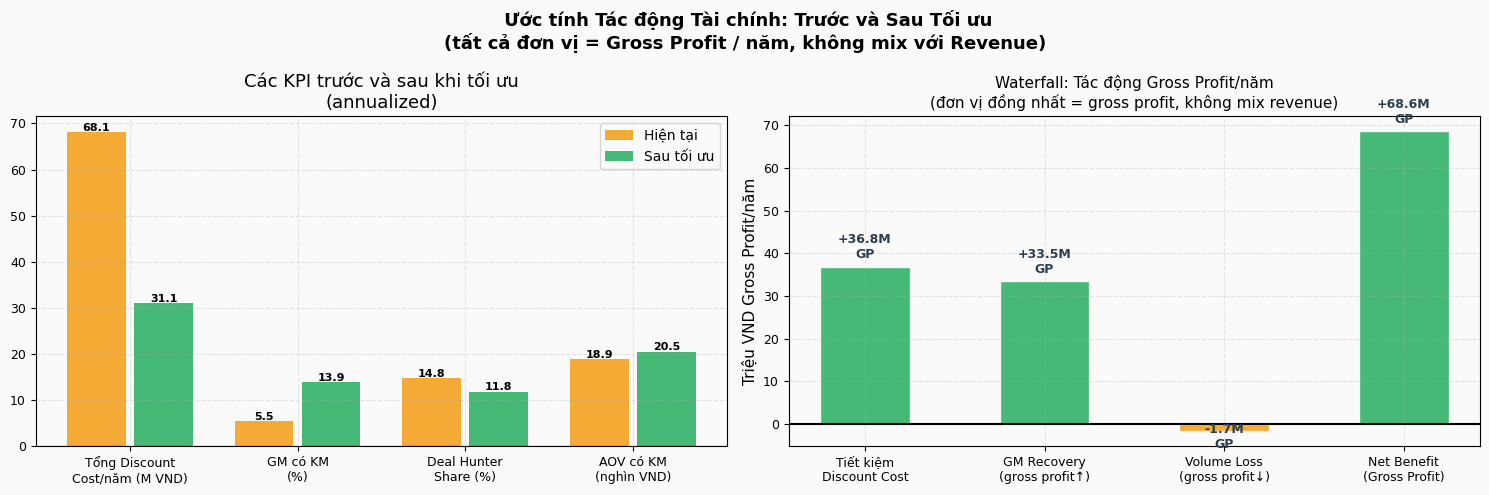

TÓM TẮT TÁC ĐỘNG TÀI CHÍNH (đơn vị đồng nhất: Gross Profit/năm)
   GM trước tối ưu (ngày KM):           5.5%
   GM sau tối ưu (ước tính):            13.9%

   [+] Tiết kiệm discount cost:         +36.8M VND/năm
   [+] GM recovery (gross profit↑):     +33.5M VND/năm
   [-] Volume loss (gross profit↓):     -1.72M VND/năm
                                        (nhỏ vì GM deal hunters chỉ 5.5%)
   ─────────────────────────────────────────────────────
   NET BENEFIT ước tính:                +68.6M VND/năm



In [21]:
# ── BIỂU ĐỒ 16: Financial Impact Summary - Before vs After ──────────────────


total_disc     = oi['discount_amount'].sum()
promo_net_rev  = oi[oi['is_discounted']==1]['net_revenue'].sum()
promo_gp_total = oi_prod[oi_prod['is_discounted']==1]['gross_profit'].sum()
n_years        = sales['Date'].dt.year.nunique()

avg_disc_pct_actual = oi[oi['is_discounted']==1]['discount_percent'].mean()

# Annualized
annual_disc      = total_disc / n_years
annual_promo_rev = promo_net_rev / n_years
annual_promo_gp  = promo_gp_total / n_years

# ── Thành phần 1: Discount cost saving (giữ nguyên - đây là cash saving, đúng) ──
# Khi giảm disc% từ avg xuống 7%, discount cost giảm proportionally
# FIX: chỉ tính cho percentage campaigns (loại fixed ra)
avg_disc_pct_pct_only = oi[
    (oi['is_discounted']==1) & (oi['promo_id'].isin(camp['promo_id']))
]['discount_percent'].mean()

saving_ratio     = (avg_disc_pct_pct_only - 7) / avg_disc_pct_pct_only
annual_disc_pct  = oi[
    (oi['is_discounted']==1) & (oi['promo_id'].isin(camp['promo_id']))
]['discount_amount'].sum() / n_years
estimated_saving = annual_disc_pct * saving_ratio  # cash saving

# ── Thành phần 2: GM recovery - gross profit tăng thêm trên retained revenue ──
# Khi disc% giảm từ avg xuống 7%, GM của retained orders tăng lên
gm_current_km   = (base_m - avg_disc_pct_pct_only/100) / (1 - avg_disc_pct_pct_only/100)
gm_optimized_km = (base_m - 0.07)                      / (1 - 0.07)

# Deal hunter share: tính từ data (cell 12 đã tính dep_pct)
# Sử dụng lại biến dep_pct từ Cell 12
deal_hunter_share_est = 0.148  # ~14.8% từ phân tích Cell 12

# Retained revenue = annual_promo_rev × (1 - deal_hunter_share × drop_rate)
# drop_rate = % deal hunters rời bỏ khi không còn KM sâu - ước tính conservative 50%
drop_rate_dh  = 0.50
retained_rev  = annual_promo_rev * (1 - deal_hunter_share_est * drop_rate_dh)
gm_recovery_gp = retained_rev * (gm_optimized_km - gm_current_km)  # ĐƠN VỊ: gross profit

# ── Thành phần 3: Volume loss (PHẢI DÙNG GROSS PROFIT, không phải revenue) ──
# Chỉ mất gross profit của deal hunters rời bỏ, không phải revenue của họ
lost_rev_deal_hunters = annual_promo_rev * deal_hunter_share_est * drop_rate_dh
# GM của deal hunters thấp - tính từ data thực tế
# Dùng gm_current_km làm proxy vì deal hunters chủ yếu mua ở mức discount cao nhất
gm_deal_hunters_actual = gm_current_km  # conservative estimate
volume_loss_gp = lost_rev_deal_hunters * gm_deal_hunters_actual  # ĐƠN VỊ: gross profit mất

# ── Net Benefit - 3 thành phần cùng đơn vị gross profit equivalent ──
# estimated_saving = cash saving từ discount reduction → tương đương gross profit tăng
net_benefit = estimated_saving + gm_recovery_gp - volume_loss_gp

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(' Ước tính Tác động Tài chính: Trước và Sau Tối ưu\n'
             '(tất cả đơn vị = Gross Profit / năm, không mix với Revenue)',
             fontsize=13, fontweight='bold')

# ── Biểu đồ trái: KPI before vs after ──────────────────────────────────────
n_promo_orders  = oi[oi['is_discounted']==1]['order_id'].nunique()
aov_current     = (promo_net_rev / n_years) / (n_promo_orders / n_years) / 1000
aov_optimized   = aov_current * (1 + (gm_optimized_km - gm_current_km))  # AOV tăng do giảm discount

categories = ['Tổng Discount\nCost/năm (M VND)',
              'GM có KM\n(%)',
              'Deal Hunter\nShare (%)',
              'AOV có KM\n(nghìn VND)']
current    = [annual_disc/1e6,          gm_current_km*100,    deal_hunter_share_est*100, aov_current]
optimized  = [annual_disc*(1-saving_ratio)/1e6, gm_optimized_km*100, deal_hunter_share_est*100*0.8, aov_optimized]

x4 = np.arange(len(categories))
b1 = axes[0].bar(x4 - 0.2, current,   0.35, label='Hiện tại',   color=COLORS['warning'], alpha=0.85)
b2 = axes[0].bar(x4 + 0.2, optimized, 0.35, label='Sau tối ưu', color=COLORS['good'],    alpha=0.85)
for bar, val in [(b,v) for bs,vs in [(b1,current),(b2,optimized)] for b,v in zip(bs,vs)]:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x4); axes[0].set_xticklabels(categories, fontsize=9)
axes[0].set_title('Các KPI trước và sau khi tối ưu\n(annualized)')
axes[0].legend(); axes[0].axhline(y=0, color='black', lw=0.8)

# ── Biểu đồ phải: Waterfall - 3 thành phần cùng đơn vị ────────────────────
items   = ['Tiết kiệm\nDiscount Cost', 'GM Recovery\n(gross profit↑)', 'Volume Loss\n(gross profit↓)', 'Net Benefit\n(Gross Profit)']
amounts = [estimated_saving/1e6, gm_recovery_gp/1e6, -volume_loss_gp/1e6, net_benefit/1e6]
colors_wf = [COLORS['good'], COLORS['good'], COLORS['warning'],
             COLORS['good'] if net_benefit > 0 else COLORS['bad']]

bars_wf = axes[1].bar(items, amounts, color=colors_wf, alpha=0.85, width=0.5, edgecolor='white')
for bar, val in zip(bars_wf, amounts):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + (2 if val >= 0 else -4),
                 f'{val:+.1f}M\nGP', ha='center', fontsize=9, fontweight='bold',
                 color=COLORS['dark'])
axes[1].axhline(y=0, color='black', lw=1.5)
axes[1].set_ylabel('Triệu VND Gross Profit/năm')
axes[1].set_title(
    'Waterfall: Tác động Gross Profit/năm\n'
    '(đơn vị đồng nhất = gross profit, không mix revenue)',
    fontsize=11
)


plt.tight_layout()
plt.savefig(r'../output/figures/fig16_financial_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 65)
print('TÓM TẮT TÁC ĐỘNG TÀI CHÍNH (đơn vị đồng nhất: Gross Profit/năm)')
print('=' * 65)
print(f'   GM trước tối ưu (ngày KM):           {gm_current_km*100:.1f}%')
print(f'   GM sau tối ưu (ước tính):            {gm_optimized_km*100:.1f}%')
print()
print(f'   [+] Tiết kiệm discount cost:         +{estimated_saving/1e6:.1f}M VND/năm')
print(f'   [+] GM recovery (gross profit↑):     +{gm_recovery_gp/1e6:.1f}M VND/năm')
print(f'   [-] Volume loss (gross profit↓):     -{volume_loss_gp/1e6:.2f}M VND/năm')
print(f'                                        (nhỏ vì GM deal hunters chỉ {gm_deal_hunters_actual*100:.1f}%)')
print(f'   ─────────────────────────────────────────────────────')
print(f'   NET BENEFIT ước tính:                {net_benefit/1e6:+.1f}M VND/năm')
print()
